<a href="https://colab.research.google.com/github/TonzandBenz007/Bookapp_011/blob/main/quickstarts/Get_started_managed_agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini Agents API: Build managed agents with the Interactions API

<a class="tfo-notebook-buttons" target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_managed_agents.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

The [Interactions API](https://ai.google.dev/gemini-api/docs/interactions) provides a unified interface for working with Gemini models and agents. The [Getting Started notebook](./Get_started_interactions_api.ipynb) covers how to use it with standard Gemini **models** for text generation, multi-turn conversations, and tool use.

This notebook focuses on something different: **managed agents** with the `antigravity-preview-05-2026` agent.

### `agent=` vs `model=`

When you call the Interactions API, you choose between two modes:

| Parameter | What runs | Best for |
|-----------|-----------|----------|
| `model="gemini-..."` | A standard Gemini model | Text generation, structured output, function calling |
| `agent="antigravity-preview-05-2026"` | A **managed agent** in a sandboxed Linux environment | Autonomous tasks: code execution, web research, file management |

With `model=`, you get a stateless LLM call (see the [Getting Started notebook](./Get_started_interactions_api.ipynb)). With `agent=`, you spin up an autonomous agent that can **reason, plan, write and execute code, browse the web, and manage files** — all inside a secure sandbox, without you writing any orchestration logic.

This notebook walks you through the agent mode step by step:

1. **Simple questions** — use the agent like an LLM (it works, but it's overkill!)
2. **Multi-turn conversations** — persistent sandbox = built-in memory
3. **Using tools** — code execution, web search, file operations
4. **Loading data into the sandbox** — inject files before the agent starts
5. **Creating reusable custom agents** — bundle instructions, skills, and environment

<a name="setup"></a>
## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai). It's recommended to always use the latest version.

In [ ]:
%pip install -U -q "google-genai>=2.9.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.53.0 which is incompatible.
google-cloud-aiplatform 1.148.1 requires google-genai<2.0.0,>=1.66.0; python_version >= "3.10", but you have google-genai 2.4.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.4.0 which is incompatible.


### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

### Initialize SDK client

With the new SDK, now you only need to initialize a client with you API key.

In [ ]:
import uuid
from google import genai
from google.genai import types
from IPython.display import Markdown

client = genai.Client(api_key=GEMINI_API_KEY)

# The default managed agent.
AGENT = "antigravity-preview-05-2026"

# Generate a unique suffix for this notebook session to prevent agent ID conflicts
UNIQUE_SUFFIX = uuid.uuid4().hex[:8]

print("Client ready!")

Client ready!


## 1. Simple questions — the agent as an LLM

The simplest way to use a managed agent is to ask it a question, just like you'd call a standard Gemini model. Pass `agent="antigravity-preview-05-2026"` and `environment="remote"` to create a fresh Linux sandbox for the agent.

This works, but it's a bit like driving a Formula 1 car to the grocery store — the agent has code execution, web search, and file management capabilities that are all sitting idle for a simple factual question.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input="What is the capital of France?",
    environment="remote",
)

Markdown(interaction.output_text)

/tmp/ipykernel_2790/271594579.py:1: UserWarning: Interactions usage is experimental and may change in future versions.
  interaction = client.interactions.create(


The capital of France is Paris.

In [ ]:
# The response also includes metadata about the agent's sandbox.
print(f"Status:         {interaction.status}")
print(f"Interaction ID: {interaction.id}")
print(f"Environment ID: {interaction.environment_id}")

Status:         completed
Interaction ID: v1_Chc1SlFNYXVmUE51YXNqckVQM09laGlBYxIXNUpRTWF1ZlBOdWFzanJFUDNPZWhpQWM
Environment ID: fc155701-ea68-4846-973f-f2943e35cdde


Notice the `environment_id` in the response. That's the agent's persistent Linux sandbox. Even for this simple question, a full container was provisioned. Let's make use of that persistence next.

## 2. Multi-turn conversations

Since each agent runs in a persistent sandbox, you can **continue where you left off** by reusing the `environment_id` and linking turns with `previous_interaction_id`.

This is fundamentally different from stateless `model=` calls. The agent has a true *persistent environment* — files it creates stick around, packages it installs remain available, and conversation context is preserved.

In [ ]:
# Turn 1: Introduce yourself.
turn1 = client.interactions.create(
    agent=AGENT,
    input="Hi! My name is Alice and I'm a software engineer. Remember that in a knowledge.md doc.",
    environment= "remote",
)

Markdown(f"**Turn 1:** {turn1.output_text}")

**Turn 1:** Hi Alice! Nice to meet you. 

I have created a `knowledge.md` file in the working directory and saved your profile details:
* **Name:** Alice
* **Role:** Software Engineer

I'll keep this in mind for our future interactions! Let me know how I can help you with your tasks today.

In [ ]:
# Turn 2: Ask whether the agent remembers.
# Pass environment_id and previous_interaction_id to continue the conversation.
turn2 = client.interactions.create(
    agent=AGENT,
    input="what's my name and what do I do?",
    environment= turn1.environment_id,
)

Markdown(f"**Turn 2:** {turn2.output_text}")

**Turn 2:** Based on the information in `knowledge.md`, here are your details:

* **Name:** Alice
* **What you do:** You are a Software Engineer.

The agent remembered across turns because you passed `environment` with the previous environment ID — same sandbox, which means same files.

You could have achieved the same result using `previous_interaction_id` to keep the history of the previous conversation, but that would not have showcased the environement specificities.

This is how you build stateful, multi-turn workflows. See the [Getting Started notebook](./Get_started_interactions_api.ipynb) for `model=`-based multi-turn using `previous_interaction_id` alone (without environments).

## 3. Using tools — where the agent shines

This is where managed agents go beyond a standard chat model. The antigravity-preview-05-2026 agent has **built-in tools** it uses autonomously — you don't declare them, just describe your goal and the agent figures out what to use.

| Tool | Description |
|------|-------------|
| `bash` | Execute shell commands in the sandbox |
| `google_search` | Search the web for current information |
| `url_context` | Fetch and extract text from URLs |
| `write_file` | Create or overwrite files in the sandbox |
| `read_file` | Read file contents from the sandbox |
| `list_files` | List directory contents |
| `delete_file` | Remove files from the sandbox |

For the standard `model=`-based tools (Google Search grounding, code execution, function calling), see the [Getting Started notebook](./Get_started_interactions_api.ipynb) and the dedicated tool notebooks:
- [Code Execution](./Code_Execution.ipynb)
- [Search Grounding](./Search_Grounding.ipynb)
- [Function Calling](./Function_calling.ipynb)

### Code execution

Ask a computational question and the agent will write code, run it in its sandbox, and return the verified result.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Write a Python script that computes the first 20 Fibonacci numbers. "
        "Run it and show the output."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have created and executed a Python script to compute the first 20 Fibonacci numbers.

### Python Script (`fibonacci.py`)

Here is the code written to `fibonacci.py`:

```python
def fibonacci(n):
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    
    fib_sequence = [0, 1]
    while len(fib_sequence) < n:
        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])
    return fib_sequence

if __name__ == "__main__":
    n = 20
    fib_numbers = fibonacci(n)
    print(f"The first {n} Fibonacci numbers are:")
    print(fib_numbers)
```

### Execution Output

Running this script yields the following result:

```text
The first 20 Fibonacci numbers are:
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]
```

### Inspecting steps — what the agent actually did

The `steps` field in the response shows the agent's reasoning chain: its thoughts, tool calls, tool results, and final output. This is useful for debugging and understanding the agent's behavior.

In [ ]:
# Inspect the steps from the Fibonacci interaction above.
for i, step in enumerate(interaction.steps):
    step_type = step.type
    print(f"--- Step {i} [{step_type}] ---")

    # Tool call steps show which tool was invoked and with what arguments.
    if hasattr(step, "name") and step.name:
        print(f"  Tool: {step.name}")
        if hasattr(step, "arguments"):
            args_str = str(step.arguments)[:300]
            print(f"  Args: {args_str}")

    # Content steps contain the agent's text output.
    if hasattr(step, "content") and step.content:
        for c in step.content:
            if hasattr(c, "text"):
                print(f"  Text: {c.text[:300]}")
    print()

--- Step 0 [thought] ---

--- Step 1 [function_call] ---
  Tool: write_file
  Args: {'path': '/fibonacci.py', 'content': 'def fibonacci(n):\n    if n <= 0:\n        return []\n    elif n == 1:\n        return [0]\n    \n    fib_sequence = [0, 1]\n    while len(fib_sequence) < n:\n        fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])\n    return fib_sequence\n\nif __name_

--- Step 2 [function_result] ---
  Tool: write_file

--- Step 3 [code_execution_call] ---

--- Step 4 [code_execution_result] ---

--- Step 5 [model_output] ---
  Text: I have created and executed a Python script to compute the first 20 Fibonacci numbers.

### Python Script (`fibonacci.py`)

Here is the code written to `fibonacci.py`:

```python
def fibonacci(n):
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    
    fib_sequence = [0, 1]
   



### Web search

The agent can search the web autonomously when it needs up-to-date information.

In [ ]:
interaction = client.interactions.create(
    agent=AGENT,
    input="What were the top 3 news stories about Google this week? Summarize them briefly.",
    environment="remote",
)

Markdown(interaction.output_text)

The week of May 12–19, 2026, has been exceptionally busy for Google, dominated by the kickoff of **Google I/O 2026** and its preliminary event, **"The Android Show."** 

Here are the top three major news stories about Google from this week:

---

### 1. Google Unveils the "Googlebook" — The Successor to the Chromebook
Google announced a brand-new, high-end laptop class called the **Googlebook**, designed to compete directly with Apple’s MacBooks and Microsoft’s AI-centric Copilot+ PCs [1, 2]. 
* **The Software:** The laptops will run a newly designed hybrid, on-device OS codenamed **"Aluminium OS"** (based on Android and ChromeOS) [2]. 
* **Key Features:** Googlebooks are marketed as "the first laptops built from the ground up for Gemini Intelligence" [2]. They will feature a nostalgic retro-style **rainbow light bar** on the lid, along with unique interaction features like **"Magic Pointer"**—a gesture tool that lets users shake their cursor to prompt context-aware AI suggestions (e.g., automatically scheduling a calendar event from highlighted text) [1].

### 2. Android 17 Showcased Along with Hardware Exclusion Backlash
During *The Android Show*, Google gave a detailed preview of **Android 17**, highlighting deep integration with on-device AI [3, 5]. However, the announcement has triggered a wave of user dissatisfaction regarding device compatibility [4].
* **The Features:** Android 17 introduces **Gemini Intelligence**, which handles multi-step app automation and custom AI widgets [5]. Other features include **"Rambler"** (a multilingual dictation tool capable of polishing spoken text, including natural code-switching like Hinglish) and native **AirDrop compatibility** for Google's Quick Share on supported devices [5].
* **The Controversy:** Google revealed that the marquee Gemini Intelligence features require the advanced hardware specs of **Gemini Nano v3** [4]. This rules out almost all older phones—including the highly popular **Pixel 9 series** launched just a year prior—prompting widespread backlash from premium phone buyers over artificial hardware limitations [4].

### 3. Google DeepMind Launches "AI for the Planet" Climate Accelerator in APAC
Google DeepMind announced its inaugural **Asia-Pacific (APAC) Accelerator** program dedicated to environmental sustainability [6, 7].
* **The Program:** This three-month program is tailored for climate tech startups, non-profits, and research teams operating in the APAC region [7]. 
* **What it Offers:** Kicking off with an in-person bootcamp in Singapore, selected teams will receive intensive, direct mentorship from Google AI researchers, technical assistance, and support in integrating DeepMind's scientific and generative AI models to help scale real-world climate and nature resilience projects [6, 7].

---

### Sources
* [1] [PCMag: Reinventing the Laptop with Googlebook](https://www.pcmag.com/opinions/with-the-googlebook-im-betting-on-google-to-reinvent-the-laptop-again)
* [2] [Axios: Googlebook Built for Gemini](https://www.axios.com/2026/05/12/googlebook-ai-chromebook-announcement)
* [3] [CNET: Android 17 Previewed with Gemini Intelligence](https://www.cnet.com/tech/services-and-software/android-17-preview/)
* [4] [HowToGeek: Steep Requirements for Gemini Intelligence](https://www.howtogeek.com/gemini-intelligence-android-17-device-requirements/)
* [5] [Times of India: Google I/O 2026 Android 17 Updates](https://timesofindia.indiatimes.com/technology/tech-news/google-i/o-2026-android-17-updates-android-xr-gemini-intelligence-and-other-things-to-expect/articleshow/131198172.cms)
* [6] [Google Blog: Launching Google DeepMind APAC Accelerator Program](https://blog.google/innovation-and-ai/models-and-research/google-deepmind/accelerator-ai-for-the-planet/)
* [7] [ESG News: DeepMind APAC Climate Accelerator](https://esgnews.com/google-deepmind-launches-apac-ai-accelerator-to-scale-climate-nature-solutions/)

### File operations

The agent can create, read, and manage files in its sandbox. Files persist within the environment across turns.

In [ ]:
# Ask the agent to create a file, run it, and show results.
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Create a Python file called 'analysis.py' that generates 50 random numbers, "
        "computes mean, median, and standard deviation, then prints the results. "
        "Run it and show the output."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have created the Python script `analysis.py` and executed it. 

### Python Script (`analysis.py`)
```python
import random
import statistics

# Set seed for reproducibility (optional, but good for consistency)
random.seed(42)

# Generate 50 random numbers between 1 and 100
numbers = [random.uniform(1, 100) for _ in range(50)]

# Calculate statistics
mean_val = statistics.mean(numbers)
median_val = statistics.median(numbers)
stdev_val = statistics.stdev(numbers)

# Print results
print("Generated 50 random numbers:")
print([round(num, 2) for num in numbers])
print(f"\nMean: {mean_val:.4f}")
print(f"Median: {median_val:.4f}")
print(f"Standard Deviation: {stdev_val:.4f}")
```

### Execution Output
```text
Generated 50 random numbers:
[64.3, 3.48, 28.23, 23.1, 73.91, 67.99, 89.33, 9.61, 42.77, 3.95, 22.65, 51.03, 3.63, 20.68, 65.34, 54.95, 22.82, 59.34, 81.13, 1.64, 80.78, 70.12, 34.68, 16.39, 95.76, 34.32, 10.18, 10.57, 84.9, 60.77, 80.91, 73.24, 54.09, 97.34, 38.47, 55.65, 83.11, 62.23, 86.31, 58.16, 70.75, 5.54, 23.56, 29.65, 8.9, 24.05, 11.0, 28.52, 63.93, 37.12]

Mean: 45.6177
Median: 46.9002
Standard Deviation: 29.0356
```

## 4. Loading data into the agent's sandbox

You can inject files into the agent's environment **before it starts** using `sources`. This is how you provide data, configuration, or code for the agent to work with.

| Source type | Description | Best for |
|------------|-------------|----------|
| `inline` | Embed content directly (max 75 KB) | Config files, small scripts |
| `gcs` | Load from Google Cloud Storage | Large datasets |
| `repository` | Load from GitHub | Code repositories |

In [ ]:
# Inject a CSV file inline and ask the agent to analyze it.
csv_data = """name,age,city,score
              Alice,28,Paris,92
              Bob,35,London,87
              Charlie,42,Berlin,95
              Diana,31,Tokyo,88
              Eve,26,Sydney,91"""

interaction = client.interactions.create(
    agent=AGENT,
    input="Read the file data.csv, analyze it, and tell me who scored the highest.",
    environment={
        "type": "remote",
        "sources": [
            {
                "type": "inline",
                "content": csv_data,
                "target": "/workspace/data.csv",
            }
        ],
    },
)

Markdown(interaction.output_text)

Based on the data in `workspace/data.csv`, **Charlie** scored the highest with a score of **95**.

Here is a breakdown of the scores in the file:

| Name | Age | City | Score |
| :--- | :--- | :--- | :--- |
| **Charlie** | **42** | **Berlin** | **95 (Highest)** |
| Alice | 28 | Paris | 92 |
| Eve | 26 | Sydney | 91 |
| Diana | 31 | Tokyo | 88 |
| Bob | 35 | London | 87 |

You can also load from other sources:

```python
# From Google Cloud Storage
{"type": "gcs", "source": "gs://my-bucket/data/", "target": "/workspace/data/"}

# From a GitHub repository
{"type": "repository", "source": "https://github.com/user/repo", "target": "/workspace/repo/"}
```

You can combine multiple sources in a single request — the agent will have access to all of them at startup.

**Pro tip:** You can use that to add skills to you agent, as you'll see next.

## 5. Creating reusable custom agents

So far, every interaction has used the base `antigravity-preview-05-2026` agent with inline instructions. Once you've found a setup that works well, you can **persist it into a named custom agent** that bundles:

- **Instructions** — system prompt that defines the agent's behavior
- **Environment** — pre-configured sandbox with files and sources
- **Skills** — `SKILL.md` files that teach the agent specialized capabilities

This is the recommended workflow:
1. **Prototype** with `agent="antigravity-preview-05-2026"` — iterate on instructions, sources, and prompts
2. **Create** a named agent via the `/agents` endpoint
3. **Invoke** your agent by name from any client

### Creating a custom agent

In [ ]:
# Create a custom data analysis agent using the SDK.
my_agent = client.agents.create(
    id=f"my-data-analyst-{UNIQUE_SUFFIX}",
    base_agent=AGENT,
    system_instruction=(
        "You are a data analysis assistant. "
        "Always write Python code using pandas to answer questions. "
        "Show your code and output clearly. "
        "When creating visualizations, save them as PNG files."
    ),
    base_environment={
        "type": "remote",
    },
)

print(f"✓ Agent created: {my_agent.id}")

✓ Agent created: my-data-analyst


### Using a custom agent

Once created, invoke your agent by name. It will follow its instructions automatically.

In [ ]:
# Invoke the custom agent.
interaction = client.interactions.create(
    agent=f"my-data-analyst-{UNIQUE_SUFFIX}",
    input=(
        "Generate a sample dataset of 100 sales records with columns: "
        "product, region, revenue, quantity. "
        "Find the top 5 products by total revenue and show the analysis."
    ),
    environment="remote",
)

Markdown(interaction.output_text)

I have generated a sample dataset of 100 sales records and performed a data analysis to find the top 5 products by total revenue. 

The sample dataset has been successfully saved to `sales_data.csv` and the corresponding visualization has been saved as `top_products_revenue.png`.

Below is the complete, step-by-step breakdown of the Python code used, the data previews, and the detailed analysis.

---

### Step 1: Generating the Sample Dataset

We used `pandas` and `numpy` to generate a realistic set of 100 sales transactions. To make the data realistic, we mapped individual products to base prices and applied a random variance of $\pm 10\%$ to mimic real-world discounts and transactional pricing.

Here is the Python code to generate and save the dataset:

```python
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Define products and base unit prices
product_prices = {
    'Laptop': 1000,
    'Smartphone': 700,
    'Tablet': 400,
    'Headphones': 150,
    'Smartwatch': 250,
    'Monitor': 300,
    'Keyboard': 80,
    'Mouse': 50,
    'Printer': 200,
    'Router': 120
}

products = list(product_prices.keys())
regions = ['North', 'East', 'South', 'West']

# Generate 100 sales records
n_records = 100
random_products = np.random.choice(products, size=n_records)
random_regions = np.random.choice(regions, size=n_records)
random_quantities = np.random.randint(1, 15, size=n_records)

# Calculate revenue with small price variations (e.g., matching discounts/promotions)
random_revenues = []
for prod, qty in zip(random_products, random_quantities):
    base_price = product_prices[prod]
    variation = np.random.uniform(0.9, 1.1)
    revenue = round(base_price * qty * variation, 2)
    random_revenues.append(revenue)

# Create DataFrame
df = pd.DataFrame({
    'product': random_products,
    'region': random_regions,
    'revenue': random_revenues,
    'quantity': random_quantities
})

# Save to CSV
df.to_csv('sales_data.csv', index=False)
```

#### Dataset Preview (First 10 Rows of `sales_data.csv`)

| | product | region | revenue | quantity |
|---|---|---|---|---|
| **0** | Keyboard | West | $73.49 | 1 |
| **1** | Headphones | East | $485.75 | 3 |
| **2** | Mouse | North | $540.04 | 10 |
| **3** | Smartwatch | West | $3,079.86 | 12 |
| **4** | Keyboard | South | $619.40 | 8 |
| **5** | Router | South | $1,280.19 | 11 |
| **6** | Tablet | East | $2,508.46 | 6 |
| **7** | Keyboard | West | $690.83 | 8 |
| **8** | Mouse | North | $484.84 | 9 |
| **9** | Smartwatch | South | $1,055.98 | 4 |

---

### Step 2: Analyzing the Top 5 Products by Total Revenue

Using `pandas`, we grouped the dataset by **product**, aggregated the total revenue and quantities, and extracted the top 5 highest-grossing products.

```python
import pandas as pd

# Load the generated dataset
df = pd.read_csv('sales_data.csv')

# Group and aggregate
product_analysis = df.groupby('product').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    average_transaction_value=('revenue', 'mean'),
    transaction_count=('product', 'count')
).reset_index()

# Sort by revenue and get top 5
top_5_products = product_analysis.sort_values(by='total_revenue', ascending=False).head(5)

# Format and display
formatted_top_5 = top_5_products.copy()
formatted_top_5['total_revenue'] = formatted_top_5['total_revenue'].map('${:,.2f}'.format)
formatted_top_5['average_transaction_value'] = formatted_top_5['average_transaction_value'].map('${:,.2f}'.format)
print(formatted_top_5.to_string(index=False))
```

#### Analysis Output

| product | total_revenue | total_quantity | average_transaction_value | transaction_count |
| :--- | :--- | :--- | :--- | :--- |
| **Laptop** | \$54,845.99 | 54 | \$7,835.14 | 7 |
| **Smartphone** | \$48,213.02 | 70 | \$4,821.30 | 10 |
| **Tablet** | \$20,754.26 | 49 | \$2,306.03 | 9 |
| **Smartwatch** | \$17,331.45 | 70 | \$1,733.14 | 10 |
| **Printer** | \$14,501.77 | 71 | \$1,208.48 | 12 |

#### Key Insights from the Product Analysis
1. **Laptops** generated the highest total revenue (**\$54,845.99**), despite having a lower transaction count (7) and total quantity sold (54). This is driven by their high unit value, resulting in a high average transaction value of **\$7,835.14**.
2. **Smartphones** are a close second with **\$48,213.02** in total revenue, driven by solid volume (70 units across 10 transactions).
3. **Printers** saw the highest volume of transactions (12) and units sold (71) among the top 5, but because of their lower unit price, they sit in fifth place with **\$14,501.77** in revenue.

---

### Step 3: Visualizing the Results

We used `matplotlib` and `seaborn` to build a publication-quality bar chart representing the top 5 products and saved it as `top_products_revenue.png`.

```python
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create barplot
barplot = sns.barplot(
    data=top_5_products,
    x='total_revenue',
    y='product',
    palette='viridis',
    hue='product',
    legend=False
)

# Annotate each bar with its revenue value
for p in barplot.patches:
    width = p.get_width()
    plt.text(
        width + 500,  # X offset
        p.get_y() + p.get_height() / 2,
        f'${width:,.2f}',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.title('Top 5 Products by Total Revenue', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Revenue (USD)', fontsize=12, labelpad=10)
plt.ylabel('Product', fontsize=12, labelpad=10)
plt.xlim(0, top_5_products['total_revenue'].max() * 1.15) # Add margin for labels

plt.tight_layout()
plt.savefig('top_products_revenue.png', dpi=300)
plt.close()
```

The resulting high-resolution chart (`top_products_revenue.png`) provides a clear visual distinction between the premium earners (Laptops and Smartphones) and the mid-tier products (Tablets, Smartwatches, and Printers).

---

### Step 4: Bonus Analysis — Regional Revenue Performance

To add more value to the analysis, we also grouped the dataset by **region** to see where sales are strongest.

```python
# Group by region
regional_sales = df.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    transaction_count=('product', 'count')
).reset_index()

# Format and display
regional_sales['total_revenue'] = regional_sales['total_revenue'].map('${:,.2f}'.format)
print(regional_sales.to_string(index=False))
```

#### Regional Performance Output

| region | total_revenue | total_quantity | transaction_count |
| :--- | :--- | :--- | :--- |
| **South** | \$75,877.06 | 210 | 31 |
| **North** | \$48,667.68 | 190 | 26 |
| **East** | \$40,204.98 | 126 | 21 |
| **West** | \$29,124.71 | 118 | 22 |

* **Regional Takeaway:** The **South** region is by far the strongest performer, contributing **\$75,877.06** in total revenue (over 39% of all sales) and leading in both quantities sold and transaction count.

### Creating an agent with pre-loaded data

You can define the agent's environment with sources, so data is ready before the agent starts:

In [ ]:
# Create an agent with GCS sources pre-loaded using the SDK.
my_slides_agent = client.agents.create(
    id=f"my-gemini-api-agent-{UNIQUE_SUFFIX}",
    base_agent=AGENT,
    system_instruction=(
        "You are a software engineer speciliazed in the Gemini API. "
        "Use the skills available in /.agents/skills/ to create amazing apps."
    ),
    base_environment={
        "type": "remote",
        "sources": [
            {
                "type": "repository",
                "source": "https://github.com/google-gemini/gemini-skills",
                "target": "/.agents/skills",
            }
        ],
    },
)

print(f"✓ Agent created: {my_slides_agent.id}")

✓ Agent created: my-gemini-api-agent


In [ ]:
# Invoke the custom agent.
interaction = client.interactions.create(
    agent=f"my-gemini-api-agent-{UNIQUE_SUFFIX}",
    input="Tell me what you can do with your skills?",
    environment="remote",
)

Markdown(interaction.output_text)

As a software engineer specializing in the **Gemini API**, I have access to three highly specialized skill sets that allow me to design, build, and deploy cutting-edge AI-driven applications. 

Here is what I can do with my specialized skills:

---

### 1. Gemini API Development (`gemini-api-dev`)
This skill covers standard, hosted model integration across multiple programming languages (Python, JavaScript/TypeScript, Go, and Java) using the modern unified `google-genai` SDKs.

*   **Implement Next-Generation Models:** I can build apps using Google's latest models, such as **Gemini 3.7 Flash** (`gemini-3.7-flash`), **Gemini 3.1 Pro** (`gemini-3.1-pro-preview`), and the **Gemma 4** open-model family (`gemma-4-31b-it`). *(Note: Legacy models like `gemini-2.0-*` and `gemini-1.5-*` are deprecated and avoided.)*
*   **Multimodal Applications:** I can build solutions that seamlessly process and analyze diverse inputs including text, high-resolution images, audio, and video files.
*   **Structured Outputs:** I can configure models to return strict, type-safe JSON data matching your precise schemas for reliable application-level parsing.
*   **Function Calling & Tool Use:** I can extend model capabilities by declaring client-side functions that the model can choose to call based on user queries, allowing real-time integrations with external APIs and databases.

---

### 2. Gemini Interactions API (`gemini-interactions-api`)
This skill focuses on stateful, timeline-based conversational flows, background research tasks, and advanced autonomous agent architectures. It adheres to the modern May 2026 schema, which utilizes a structured `steps` timeline.

*   **Stateful Conversations:** I can build chat applications that maintain server-side interaction history, making multi-turn chat simpler and more context-rich without having to manually pass complete histories back and forth.
*   **Deep Research Agent Orchestration:** I can construct autonomous pipelines using agents like `deep-research-preview-04-2026` to run background, multi-step, interactive research tasks with automatic progress-polling patterns.
*   **Remote Managed Agents:** I can spin up and orchestrate **Antigravity Agents** (`antigravity-preview-05-2026`) operating in remote, Google-hosted Linux sandboxes. These agents can autonomously execute Python or Node.js code, run Bash commands, manage remote workspaces, and search the web.
*   **Custom Multi-Agent Systems:** I can program custom remote agents by defining base environments, seeding GitHub repositories directly into the sandboxes, and overriding system instructions to build dedicated code-reviewers, data-analysts, or security auditors.

---

### 3. Gemini Live API Development (`gemini-live-api-dev`)
This skill allows me to build low-latency, real-time, bidirectional voice and video streaming experiences over WebSockets.

*   **Low-Latency Audio Conversations:** Using `gemini-3.1-flash-live-preview`, I can configure continuous microphone-to-speaker conversational apps with automatic Voice Activity Detection (VAD) and smart interruption handling (e.g., clearing the playback queue if the user speaks over the assistant).
*   **Video Frame Streaming:** I can feed continuous camera or screen-share streams (such as JPEG-encoded frames) to the live session alongside raw PCM audio inputs to create interactive visual companions.
*   **Real-Time Native "Thinking":** I can adjust the model's performance on the fly by configuring its `thinkingLevel` (from minimal to high) to trade off between complex reasoning depth and ultra-low latency.
*   **Production-Ready Audio Integrations:** I can deploy and configure Live API connectors for third-party WebRTC/WebSocket frameworks like **LiveKit**, **Pipecat (Daily)**, **Fishjam**, and **Vision Agents**.
*   **Secure Ephemeral Tokens:** I can implement secure authentication pipelines that generate short-lived, client-side ephemeral tokens so your browser or mobile client can communicate directly with the Gemini Live WebSocket server without ever exposing your private API keys.

***

### How I Can Help You Today
Whether you want to create a **real-time voice-activated assistant**, launch a **stateful research agent that browses and writes code**, or simply **migrate a legacy `generateContent` codebase to the modern May 2026 schema**, I am fully equipped to design and implement the complete architecture for you. 

Let me know what kind of application you would like to build!

### Forking from an existing environment

If you've already set up a sandbox you like (installed packages, created files, etc.), you can fork it into a new agent using the `environment_id` from a previous interaction:

```python
my_forked_agent = client.agents.create(
    id="my-forked-agent",
    base_agent=AGENT,
    system_instruction="Your custom instructions here.",
    base_environment={"env_id": "YOUR_ENVIRONMENT_ID"},
)
```

This captures the exact state of that sandbox — all installed packages, files, and configuration.

In [ ]:
my_forked_agent = client.agents.create(
    id="my-forked-agent",
    base_agent="my-gemini-api-agent",
    system_instruction="I want all your apps to use the Live API",
    base_environment={"env_id": interaction.environment_id},
)
print(f"✓ Agent forked: {my_forked_agent.id}")

✓ Agent forked: my-forked-agent


### Managing agents (CRUD)

The `/agents` endpoint supports full lifecycle management:

In [ ]:
# List all your agents.
print("Your agents:")
for agent in client.agents.list().agents:
    print(f"- {agent.id}")

# Get a specific agent's details.
agent = client.agents.get(id="my-data-analyst")
print(f"\nAgent details for {agent.id}:")
print(f"Base agent: {agent.base_agent}")
print(f"System instruction: {agent.system_instruction}")

Your agents:
- $AGENT_ID
- code-reviewer
- data-analyst
- my-gemini-api-agent
- my-forked-agent

Agent details for my-data-analyst:
Base agent: antigravity-preview-05-2026
System instruction: You are a data analysis assistant. Always write Python code using pandas to answer questions. Show your code and output clearly. When creating visualizations, save them as PNG files.


In [ ]:
# Clean up: delete the agents you created.
for agent_name in ["my-data-analyst", "my-forked-agent", "my-gemini-api-agent"]:
    try:
        client.agents.delete(id=agent_name)
        print(f"✓ Deleted {agent_name}")
    except Exception as e:
        print(f"  Failed to delete {agent_name}: {e}")

✓ Deleted my-data-analyst
✓ Deleted my-forked-agent
✓ Deleted my-gemini-api-agent


### Agent directory structure

Behind the API, an agent is defined by a simple set of files. This is what gets deployed when you create one:

```
my-agent/
├── agent.yaml       # Configuration: base agent, tools, environment
├── AGENTS.md        # System instructions (loaded automatically)
├── skills/          # Custom SKILL.md files that extend capabilities
└── workspace/       # Files seeded into the remote sandbox at startup
```

- **`agent.yaml`** maps directly to the `/agents` API resource
- **`AGENTS.md`** provides system instructions — automatically loaded by the harness
- **`skills/`** contains specialized `SKILL.md` files the agent discovers and uses
- **`workspace/`** files are injected into the sandbox at startup

This file-based structure makes agents easy to version-control, share, and iterate on. Check the [documentation](https://ai.google.dev/gemini-api/docs/custom-agents#file-based_customization) for more details.

## 6. Streaming

For longer tasks, enable streaming with `stream=True` to get real-time updates as the agent works. Instead of waiting for the complete response, you receive a stream of **Server-Sent Events (SSE)** that let you show progress to the user.

### Event types

The stream delivers events that tell you what the agent is doing:

| Event type | Meaning | What to do |
|------------|---------|------------|
| `interaction.created` | The interaction was created | Store the `id` for later reference |
| `interaction.status_update` | Status changed (e.g., `in_progress`) | Update UI status indicator |
| `step.start` | A new step began (thinking, tool call, output) | Show a loading indicator |
| `step.delta` | Incremental content — a chunk of text, thought, or tool output | **Append to display** — this is the main content |
| `step.stop` | A step completed | Hide loading indicator |
| `interaction.completed` | The agent finished all work | Finalize the UI |

The `step.delta` events are where the content lives. Each delta has a `type` (e.g., `text`, `thought`, `function_call`, `function_result`) and content you can render incrementally.

In [ ]:
# Stream a response and collect the text as it arrives.
stream = client.interactions.create(
    agent=AGENT,
    input="Write a short poem about the ocean.",
    stream=True,
    environment="remote",
)

collected_text = []

for event in stream:
    # Show the event type so you can see the lifecycle.
    if event.event_type in ("interaction.created", "step.start", "step.stop", "interaction.completed"):
        print(f"[{event.event_type}]")

    # step.delta events carry the actual content.
    elif event.event_type == "step.delta":
        delta = event.delta
        if hasattr(delta, "text") and delta.text:
            print(delta.text, end="", flush=True)
            collected_text.append(delta.text)

print(f"\n\n--- Collected {len(collected_text)} text chunks ---")

[interaction.created]
[step.start]
[step.stop]
[step.start]
Endless cradle of deep, dark blue,
Where whispered secrets of the wind come through.
With restless tides that rise and fall,
You sing an ancient song to all.

A shimmering mirror to the sky,
Where white-winged gulls and currents fly.
In depth and silence, wild and free,
The timeless heart of the mighty sea.[step.stop]
[interaction.completed]


--- Collected 4 text chunks ---


## 7. Advanced features

### Network configuration

By default, the agent's sandbox has unrestricted outbound network access. You can control this with the `network` field:
- **Allowlist specific domains** — only requests to listed domains are permitted
- **Inject credentials** — automatically add headers (API keys, tokens) to outbound requests
- **Disable network** — set `network: "disabled"` to block all outbound traffic

In [ ]:
# Allow the agent to call only the Gemini API, with an auto-injected API key.
interaction = client.interactions.create(
    agent=AGENT,
    input="Use curl to call the Gemini API and list available models. Show the first 3.",
    environment={
        "type": "remote",
        "network": {
            "allowlist": [
                {
                    "domain": "generativelanguage.googleapis.com",
                    "transform": [{"x-goog-api-key": GEMINI_API_KEY}],
                },
            ]
        },
    },
)

Markdown(interaction.output_text)

To list the available models in the Gemini API, we can send a `GET` request to the `/v1beta/models` endpoint of `generativelanguage.googleapis.com`. Because authentication is automatically handled by the environment's egress proxy, no API key or Authorization header is required.

### Curl Command

```bash
curl -s "https://generativelanguage.googleapis.com/v1beta/models"
```

### First 3 Models Returned

Here is the JSON payload of the first 3 models returned from the API response:

```json
[
  {
    "name": "models/gemini-3.7-flash",
    "version": "001",
    "displayName": "Gemini 3.7 Flash",
    "inputTokenLimit": 16777216,
    "outputTokenLimit": 2048,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
   },
  {
    "name": "models/gemini-3.7-flash",
    "displayName": "Gemini 3.5 Flash Lite",
    "description": "Gemini 3.5 Flash Lite",
    "inputTokenLimit": 1048576,
    "outputTokenLimit": 65536,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
    "temperature": 1,
    "topP": 0.95,
    "topK": 64,
  ,
    "maxTemperature": 2,
    "thinking": true
  },
  {
    "name": "models/gemini-3.1-pro-preview",
    "version": "001",
    "displayName": "Gemini 3.1 Pro Preview",
    "description": "Gemini 3.1 Pro Preview",
    "inputTokenLimit": 1048576,
    "outputTokenLimit": 65536,
    "supportedGenerationMethods": [
      "generateContent",
      "countTokens"
    ],
    "temperature": 1,
    "topP": 0.95,
    "topK": 64,
     "maxTemperature": 2,
    "thinking": true
  }
]
```

### Download environment snapshots

You can download all the files the agent created or modified as a tar archive. This lets you retrieve the agent's work products — code, data, reports — from the sandbox.

In [ ]:
import subprocess
import tarfile
import os

# Create an interaction where the agent produces files.
interaction = client.interactions.create(
    agent=AGENT,
    input=(
        "Create a directory called 'project' with a README.md and a hello.py script. "
        "List the files you created."
    ),
    environment="remote",
)

env_id = interaction.environment_id
print(f"Environment ID: {env_id}")

Markdown(interaction.output_text)

Environment ID: cbcfb191-7b88-46dc-ba0b-008e32ed7cb5


I have successfully created the `project` directory containing a `README.md` and a `hello.py` script. 

Here are the files created inside `/project`:
- `README.md` — A simple markdown documentation file.
- `hello.py` — A basic Python script that prints a greeting.

In [ ]:
# Download the environment snapshot.
download_url = (
    f"https://generativelanguage.googleapis.com/v1beta/"
    f"files/environment-{env_id}:download?alt=media"
)

result = subprocess.run(
    ["curl", "-L", "-s", "-o", "snapshot.tar",
     "-H", f"x-goog-api-key: {GEMINI_API_KEY}",
     download_url],
    capture_output=True, text=True,
)

if os.path.exists("snapshot.tar") and os.path.getsize("snapshot.tar") > 0:
    with tarfile.open("snapshot.tar") as tar:
        print("Files in snapshot:")
        for member in tar.getmembers():
            print(f"  {member.name} ({member.size} bytes)")
else:
    print("Snapshot not available (environment may have expired).")

Files in snapshot:
  . (0 bytes)
  ./project (0 bytes)
  ./project/README.md (74 bytes)
  ./project/hello.py (93 bytes)


## Next steps

You've walked through the core capabilities of managed agents:

1. ✅ **Simple Q&A** — the agent can answer questions like an LLM
2. ✅ **Multi-turn** — persistent sandbox enables stateful conversations
3. ✅ **Built-in tools** — code execution, web search, file management
4. ✅ **Data loading** — inject files via inline, GCS, or GitHub sources
5. ✅ **Custom agents** — reusable configurations with instructions, skills, and environment
6. ✅ **Streaming** — real-time updates as the agent works
7. ✅ **Advanced** — network control and environment snapshots

### Learn more

- **[Getting Started notebook](./Get_started_interactions_api.ipynb)** — the `model=`-based Interactions API for standard generation, multi-turn, and tools
- **[Managed Agents documentation](https://ai.google.dev/gemini-api/docs/eap/gemini-agents/gemini-agents)** — full reference for the agent API
- **[Code Execution](./Code_Execution.ipynb)** — model-based code execution
- **[Search Grounding](./Search_Grounding.ipynb)** — model-based web search
- **[Function Calling](./Function_calling.ipynb)** — custom function declarations

1.Import data

In [1]:
import pandas as pd

In [10]:
df = pd.read_csv('winequality-red.csv'  , sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Step 1: โหลดและเตรียมข้อมูล (Data Preparation)**ทำข้อความเป็นตัวหนา:** **ทำข้อความเป็นตัวหนา**

In [4]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


def step_1_prepare_data():
  print("--- Step 1: โหลดและเตรียมข้อมูล ---")
  data = load_iris()
  X = pd.DataFrame(data.data, columns=data.feature_names)
  y = pd.Series(data.target)

  # แบ่งข้อมูล Train 80% / Test 20%
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  print(f"ข้อมูล Train: {X_train.shape[0]} แถว")
  print(f"ข้อมูล Test: {X_test.shape[0]} แถว")
  return X_train, X_test, y_train, y_test, data.target_names


if __name__ == "__main__":
  X_train, X_test, y_train, y_test, target_names = step_1_prepare_data()

--- Step 1: โหลดและเตรียมข้อมูล ---
ข้อมูล Train: 120 แถว
ข้อมูล Test: 30 แถว


Step 2: การแปลงข้อมูล (Feature Engineering / Scaling)
สเต็ปนี้ปรับสเกลข้อมูลให้มีมาตรฐานเดียวกัน ป้องกันไม่ให้ฟีเจอร์ที่มีตัวเลขค่าสูงกว่าไปครอบงำโมเดล และบันทึก scaler **เก็บไว้ใช้ตอนทำนายจริง**

In [5]:
import joblib
from sklearn.preprocessing import StandardScaler


def step_2_scale_features(X_train, X_test):
  print("--- Step 2: การแปลงข้อมูล (Scaling) ---")
  scaler = StandardScaler()

  # Fit และ Transform ข้อมูล Train, แต่ Transform เฉพาะข้อมูล Test เพื่อป้องกัน Data Leakage
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # บันทึก Scaler ไว้ใช้ตอน Inference
  joblib.dump(scaler, "scaler.pkl")
  print("แปลงสเกลและบันทึก scaler.pkl เรียบร้อยแล้ว")

  return X_train_scaled, X_test_scaled

Step 3: สร้างและฝึกสอนโมเดล (Model Training)
สเต็ปนี้เลือกอัลกอริทึม Machine Learning **และป้อนข้อมูลที่ผ่านการสเกลแล้วเข้าไปให้โมเดลเรียนรู้**

In [6]:
import joblib
from sklearn.ensemble import RandomForestClassifier


def step_3_train_model(X_train_scaled, y_train):
  print("--- Step 3: สร้างและฝึกสอนโมเดล ---")
  # สร้างโมเดล Random Forest
  model = RandomForestClassifier(n_estimators=100, random_state=42)

  # เทรนโมเดล
  model.fit(X_train_scaled, y_train)
  print("เทรนโมเดลสำเร็จ!")

  return model

Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation)
สเต็ปนี้ทดสอบโมเดลกับชุดข้อมูลทดสอบ (X_test) ที่เตรียมไว้ แล้ววัดประสิทธิภาพความแม่นยำ

In [7]:
from sklearn.metrics import accuracy_score, classification_report


def step_4_evaluate_model(model, X_test_scaled, y_test, target_names):
  print("--- Step 4: ประเมินประสิทธิภาพโมเดล ---")
  y_pred = model.predict(X_test_scaled)

  acc = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำ (Accuracy): {acc * 100:.2f}%\n")
  print("รายงานผลอย่างละเอียด:")
  print(classification_report(y_test, y_pred, target_names=target_names))

Step 5: บันทึกโมเดล (Model Saving)
สเต็ปสุดท้ายในการจัดเก็บโมเดลที่ผ่านการเทรนแล้วลงในไฟล์ เพื่อนำไปใช้จริงในระบบ Production

In [8]:
import joblib


def step_5_save_model(model):
  print("--- Step 5: บันทึกโมเดล ---")
  joblib.dump(model, "iris_model.pkl")
  print("บันทึกโมเดลลงไฟล์ 'iris_model.pkl' สำเร็จ!")

นำมารวมกันรันเป็น Pipeline หลัก

In [9]:
if __name__ == "__main__":
  # 1. เตรียมข้อมูล
  X_train, X_test, y_train, y_test, target_names = step_1_prepare_data()
  print("\n")

  # 2. แปลงสเกลข้อมูล
  X_train_scaled, X_test_scaled = step_2_scale_features(X_train, X_test)
  print("\n")

  # 3. เทรนโมเดล
  model = step_3_train_model(X_train_scaled, y_train)
  print("\n")

  # 4. ประเมินผล
  step_4_evaluate_model(model, X_test_scaled, y_test, target_names)
  print("\n")

  # 5. บันทึกโมเดล
  step_5_save_model(model)

--- Step 1: โหลดและเตรียมข้อมูล ---
ข้อมูล Train: 120 แถว
ข้อมูล Test: 30 แถว


--- Step 2: การแปลงข้อมูล (Scaling) ---
แปลงสเกลและบันทึก scaler.pkl เรียบร้อยแล้ว


--- Step 3: สร้างและฝึกสอนโมเดล ---
เทรนโมเดลสำเร็จ!


--- Step 4: ประเมินประสิทธิภาพโมเดล ---
ความแม่นยำ (Accuracy): 100.00%

รายงานผลอย่างละเอียด:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



--- Step 5: บันทึกโมเดล ---
บันทึกโมเดลลงไฟล์ 'iris_model.pkl' สำเร็จ!


EDA DATA

In [11]:
df.iloc[:, :-1].describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [12]:
df['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


In [13]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


3.Preprocessing data

In [14]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np


In [16]:
bins = [2 , 6.5 , 8]
group_names = ['bad' , 'good']
df['quality'] = pd.cut(df['quality'] , bins = bins , labels = group_names)

In [17]:
df['quality'].value_counts()

,count
quality,
bad,1382
good,217


In [18]:
encoder = LabelEncoder()
df['quality'] = encoder.fit_transform(df['quality'])

In [19]:
df['quality'].value_counts()

,count
quality,
0,1382
1,217


In [21]:
df_major = df[df["quality"] == 0]
df_minor = df[df["quality"] == 1]

df_minor_oversampled = df_minor.sample(len(df_major), replace=True)

df_oversampled = pd.concat([df_major, df_minor_oversampled])
x = df_oversampled.drop('quality', axis=1)
y = df_oversampled['quality']

In [22]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
37      1
206     1
1067    1
1043    1
505     1
Name: quality, Length: 2764, dtype: int64>

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((1934, 11), (830, 11))

Build the model

In [26]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [28]:
clf_pipeline = [('scaling' , StandardScaler()),
                ('clf', SVC(random_state=42))]
pipeline = Pipeline(clf_pipeline)

In [29]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)


The performandce of the model

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [33]:
confusion_matrix(y_test, y_pred)

array([[355,  72],
       [ 56, 347]])

In [34]:
accuracy_score(y_test, y_pred)

0.8457831325301205

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       427
           1       0.83      0.86      0.84       403

    accuracy                           0.85       830
   macro avg       0.85      0.85      0.85       830
weighted avg       0.85      0.85      0.85       830



Save the model

In [37]:
from pathlib import Path
import os
import joblib

In [39]:
PATH_SAVE = 'model'
MODEL_NAME = 'SVC'
if not os.path.isdir(PATH_SAVE):
  print('create path models')
  os.mkdir(PATH_SAVE)
else:
  print('model path is exist.')
PATH_FILE = Path(PATH_SAVE) / f"{MODEL_NAME}.pkl"
PATH_FILE

create path models


PosixPath('model/SVC.pkl')

In [41]:
joblib.dump(pipeline, PATH_FILE)

['model/SVC.pkl']

In [42]:
from joblib import load

Testing the loaded model

In [43]:
from joblib import load


In [46]:
load_model = load('./model/SVC.pkl')

In [ ]:
colums

In [49]:
load_model.predict(X_test)

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,

โค้ด Python สำหรับการ Train Model (Plantar Fasciitis Prediction Pipeline)

In [31]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def run_training_pipeline():
  print(
      "--- Step 1: สร้างและเตรียมข้อมูลจำลอง (Synthetic Data Preparation) ---"
  )
  # กำหนด Seed เพื่อให้ผลลัพธ์คงที่
  np.random.seed(42)
  n_samples = 1000

  # จำลองฟีเจอร์ต่างๆ เช่น BMI, อายุ, ความหนาของพังผืดใต้ฝ่าเท้า (mm), และระดับความเจ็บปวด (NRS 0-10)
  bmi = np.random.normal(27, 4, n_samples)  # ค่าเฉลี่ย BMI ประมาณ 27
  age = np.random.randint(20, 80, n_samples)  # อายุระหว่าง 20 ถึง 80 ปี
  fascia_thickness = np.random.normal(
      5.0, 1.5, n_samples
  )  # ความหนาพังผืด (ปกติ 2-4 มม., เป็นโรค > 4.5 มม.)
  pain_score = np.random.randint(0, 10, n_samples)  # คะแนนความเจ็บปวด

  # สร้างเงื่อนไขจำลองเป้าหมาย (Target: 1 = มีอาการ/ความเสี่ยงสูง, 0 = ปกติ)
  # อ้างอิงจากปัจจัยเสี่ยง เช่น BMI สูง และพังผืดหนา
  target = (
      (bmi > 26) & (fascia_thickness > 4.2) & (pain_score > 3)
  ).astype(int)

  # รวมเป็น DataFrame
  df = pd.DataFrame({
      "BMI": bmi,
      "Age": age,
      "Fascia_Thickness": fascia_thickness,
      "Pain_Score": pain_score,
      "Target": target,
  })

  X = df[["BMI", "Age", "Fascia_Thickness", "Pain_Score"]]
  y = df["Target"]

  # แบ่งข้อมูลเป็น Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )
  print(f"ข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
  print(f"ข้อมูลสำหรับ Test: {X_test.shape[0]} แถว\n")

  print("--- Step 2: การแปลงและปรับสเกลข้อมูล (Feature Scaling) ---")
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  print("ปรับสเกลข้อมูลสำเร็จ\n")

  print("--- Step 3: การสร้างและฝึกสอนโมเดล (Model Training) ---")
  # ใช้ Random Forest Classifier ในการสร้างโมเดล
  model = RandomForestClassifier(n_estimators=100, random_state=42)
  model.fit(X_train_scaled, y_train)
  print("ฝึกสอนโมเดล (Model Training) เรียบร้อยแล้ว!\n")

  print("--- Step 4: การประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")
  y_pred = model.predict(X_test_scaled)
  acc = accuracy_score(y_test, y_pred)

  print(f"ความแม่นยำของโมเดล (Accuracy): {acc * 100:.2f}%")
  print("\nรายงานผลการประเมิน (Classification Report):")
  print(classification_report(y_test, y_pred))

  print("--- Step 5: การบันทึกโมเดล (Model Saving) ---")
  joblib.dump(model, "plantar_fasciitis_model.pkl")
  joblib.dump(scaler, "plantar_scaler.pkl")
  print(
      "บันทึกไฟล์โมเดล ('plantar_fasciitis_model.pkl') และตัวแปลงสเกล"
      " ('plantar_scaler.pkl') สำเร็จแล้ว!"
  )


if __name__ == "__main__":
  run_training_pipeline()

--- Step 1: สร้างและเตรียมข้อมูลจำลอง (Synthetic Data Preparation) ---
ข้อมูลสำหรับ Train: 800 แถว
ข้อมูลสำหรับ Test: 200 แถว

--- Step 2: การแปลงและปรับสเกลข้อมูล (Feature Scaling) ---
ปรับสเกลข้อมูลสำเร็จ

--- Step 3: การสร้างและฝึกสอนโมเดล (Model Training) ---
ฝึกสอนโมเดล (Model Training) เรียบร้อยแล้ว!

--- Step 4: การประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
ความแม่นยำของโมเดล (Accuracy): 100.00%

รายงานผลการประเมิน (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

--- Step 5: การบันทึกโมเดล (Model Saving) ---
บันทึกไฟล์โมเดล ('plantar_fasciitis_model.pkl') และตัวแปลงสเกล ('plantar_scaler.pkl') สำเร็จแล้ว!


(Data Simulation Pipeline)

In [50]:
import numpy as np
import pandas as pd


def simulate_plantar_fasciitis_data(n_samples=1000):
  # กำหนด Random Seed เพื่อให้สุ่มได้ค่าคงที่เหมือนกันทุกครั้งที่รัน
  np.random.seed(42)

  # 1. อายุ (Age): อ้างอิงจากช่วงอายุที่พบความผิดปกติได้บ่อย (20 - 80 ปี โดยมักพบพีคในช่วง 40-60 ปี)
  age = np.random.randint(20, 81, n_samples)

  # 2. ดัชนีมวลกาย (BMI): อ้างอิงจากช่วง BMI ของกลุ่มตัวอย่างในงานวิจัย (ประมาณ 18 - 43)[cite: 6]
  # โดยผู้ป่วยมักมีแนวโน้ม BMI สูงหรือเข้าข่ายน้ำหนักเกิน/อ้วน
  bmi = np.random.normal(27.0, 4.2, n_samples)
  bmi = np.clip(bmi, 17.5, 43.5)  # จำกัดช่วงให้อยู่ในขอบเขตที่สมจริง

  # 3. ความหนาของพังผืดใต้ฝ่าเท้า (Fascia_Thickness ในหน่วยมิลลิเมตร):
  # คนปกติมักหนา 2-4 มม.[cite: 5] แต่ผู้ป่วย Plantar Fasciitis มักพบความหนามากกว่า 4.5 มม. ขึ้นไป[cite: 1, 4]
  fascia_thickness = np.random.normal(4.8, 1.4, n_samples)
  fascia_thickness = np.clip(
      fascia_thickness, 2.0, 12.0
  )  # จำกัดให้อยู่ในช่วง 2.0 - 12.0 มม.

  # 4. คะแนนความเจ็บปวด (Pain_Score): วัดระดับความเจ็บปวดตามสเกล 0 ถึง 10 (เช่น NRS หรือ VAS)
  pain_score = np.random.randint(0, 11, n_samples)

  # กำหนดเงื่อนไขจำลองโรค (Target: 1 = มีแนวโน้มเป็นโรคพังผืดใต้ฝ่าเท้า, 0 = ปกติ)
  # อ้างอิงตามเกณฑ์ทางการแพทย์ เช่น พังผืดหนาเกิน 4.5 มม.[cite: 4] ร่วมกับมีอาการเจ็บและ BMI สูง[cite: 1, 4]
  target = (
      (fascia_thickness > 4.5) & (pain_score >= 3) & (bmi >= 24.0)
  ).astype(int)

  # รวมข้อมูลทั้งหมดลงใน Pandas DataFrame
  df = pd.DataFrame({
      "Age": age,
      "BMI": np.round(bmi, 2),
      "Fascia_Thickness_mm": np.round(fascia_thickness, 2),
      "Pain_Score": pain_score,
      "Target": target,
  })

  return df


# --- การเรียกใช้งานฟังก์ชัน ---
if __name__ == "__main__":
  # สร้างชุดข้อมูลจำลองจำนวน 1,000 แถว
  df_plantar = simulate_plantar_fasciitis_data(1000)

  print("=== ตัวอย่างข้อมูลจำลอง (5 แถวแรก) ===")
  print(df_plantar.head(), "\n")

  print("=== สรุปสถิติเบื้องต้นของชุดข้อมูล ===")
  print(df_plantar.describe())

=== ตัวอย่างข้อมูลจำลอง (5 แถวแรก) ===
   Age    BMI  Fascia_Thickness_mm  Pain_Score  Target
0   58  25.69                 3.05           0       0
1   71  20.28                 4.10           8       0
2   48  21.25                 5.19           3       0
3   34  29.25                 3.50           2       0
4   62  31.45                 5.70           0       0 

=== สรุปสถิติเบื้องต้นของชุดข้อมูล ===
               Age          BMI  Fascia_Thickness_mm   Pain_Score       Target
count  1000.000000  1000.000000          1000.000000  1000.000000  1000.000000
mean     50.879000    26.906700             4.790340     5.089000     0.331000
std      17.637558     4.143236             1.359803     3.186728     0.470809
min      20.000000    17.500000             2.000000     0.000000     0.000000
25%      36.000000    24.055000             3.830000     2.000000     0.000000
50%      51.000000    26.940000             4.810000     5.000000     0.000000
75%      67.000000    29.645000      

Feature Scaling

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# สมมติว่าเรามีฟังก์ชันจำลองข้อมูลจากสเต็ปก่อนหน้า
from __main__ import simulate_plantar_fasciitis_data


def run_feature_scaling():
  # 1. สร้างชุดข้อมูลจำลอง
  df = simulate_plantar_fasciitis_data(1000)

  # แยกFeatures (X) และ Target (y)
  X = df[["Age", "BMI", "Fascia_Thickness_mm", "Pain_Score"]]
  y = df["Target"]

  # 2. แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  print("--- ข้อมูลก่อนทำ Feature Scaling (5 แถวแรกของ Train Set) ---")
  print(X_train.head(), "\n")

  # 3. ทำ Feature Scaling ด้วย StandardScaler
  scaler = StandardScaler()

  # ใช้ fit_transform กับข้อมูล Train เพื่อคำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน แล้วแปลงข้อมูล
  X_train_scaled = scaler.fit_transform(X_train)

  # ใช้ transform (อย่างเดียว) กับข้อมูล Test เพื่อป้องกัน Data Leakage (ไม่ให้ข้อมูลชุดทดสอบไปมีผลกับการคำนวณสเกล)
  X_test_scaled = scaler.transform(X_test)

  # แปลงกลับเป็น DataFrame เพื่อให้อ่านง่ายขึ้น (สำหรับการแสดงผล)
  X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
  X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

  print("--- ข้อมูลหลังทำ Feature Scaling (5 แถวแรกของ Train Set) ---")
  print(
      X_train_scaled_df.head().to_string(index=False)
  )  # สังเกตว่าค่าเฉลี่ยจะเข้าใกล้ 0

  return X_train_scaled, X_test_scaled, y_train, y_test


if __name__ == "__main__":
  X_train_scaled, X_test_scaled, y_train, y_test = run_feature_scaling()

--- ข้อมูลก่อนทำ Feature Scaling (5 แถวแรกของ Train Set) ---
     Age    BMI  Fascia_Thickness_mm  Pain_Score
29    40  32.60                 5.17           0
535   41  24.19                 5.35           7
695   45  29.71                 3.21           4
557   71  25.67                 4.46           8
836   25  24.39                 4.29          10 

--- ข้อมูลหลังทำ Feature Scaling (5 แถวแรกของ Train Set) ---
      Age       BMI  Fascia_Thickness_mm  Pain_Score
-0.606638  1.384199             0.270049   -1.588384
-0.549976 -0.638887             0.402062    0.600334
-0.323328  0.688989            -1.167424   -0.337688
 1.149885 -0.282862            -0.250669    0.913008
-1.456568 -0.590775            -0.375347    1.538357


Model Training

In [52]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


def run_model_training(X_train_scaled, y_train, X_test_scaled, y_test):
  print("--- Step 3: การสร้างและฝึกสอนโมเดล (Model Training) ---")

  # 1. กำหนดค่าพารามิเตอร์และสร้างโมเดล RandomForestClassifier
  # n_estimators คือจำนวนต้นไม้ในป่า (Decision Trees), random_state เพื่อให้ผลลัพธ์คงที่
  model = RandomForestClassifier(
      n_estimators=100, max_depth=None, random_state=42
  )

  # 2. นำข้อมูลฝึกสอน (X_train_scaled และ y_train) เข้าไปเทรนโมเดล
  model.fit(X_train_scaled, y_train)
  print("ฝึกสอนโมเดล (Model Training) สำเร็จเรียบร้อยแล้ว!\n")

  print("--- Step 4: การประเมินประสิทธิภาพเบื้องต้น (Model Evaluation) ---")
  # 3. นำโมเดลไปทำนายผลกับชุดข้อมูลทดสอบ (X_test_scaled)
  y_pred = model.predict(X_test_scaled)

  # 4. วัดผลความแม่นยำ (Accuracy)
  acc = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำของโมเดล (Accuracy): {acc * 100:.2f}%\n")

  # 5. แสดงรายงานผลเชิงลึก (Precision, Recall, F1-Score)
  print("รายงานผลการจำแนกประเภท (Classification Report):")
  print(classification_report(y_test, y_pred))

  return model


if __name__ == "__main__":
  # ตัวอย่างการจำลองข้อมูลและทำ Scaling ต่อเนื่อง เพื่อให้โค้ดส่วนนี้รันได้ทันที
  from sklearn.model_selection import train_test_split
  from sklearn.preprocessing import StandardScaler
  from __main__ import simulate_plantar_fasciitis_data

  df = simulate_plantar_fasciitis_data(1000)
  X = df[["Age", "BMI", "Fascia_Thickness_mm", "Pain_Score"]]
  y = df["Target"]

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # เรียกใช้งานฟังก์ชันเทรนโมเดล
  trained_model = run_model_training(
      X_train_scaled, y_train, X_test_scaled, y_test
  )

--- Step 3: การสร้างและฝึกสอนโมเดล (Model Training) ---
ฝึกสอนโมเดล (Model Training) สำเร็จเรียบร้อยแล้ว!

--- Step 4: การประเมินประสิทธิภาพเบื้องต้น (Model Evaluation) ---
ความแม่นยำของโมเดล (Accuracy): 100.00%

รายงานผลการจำแนกประเภท (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       138
           1       1.00      1.00      1.00        62

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200




Model Evaluation

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def run_model_evaluation(model, X_test_scaled, y_test):
  print("--- Step 4: การประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")

  # 1. ทำนายผลจากชุดข้อมูลทดสอบ (Test Set)
  y_pred = model.predict(X_test_scaled)

  # 2. วัดผลความแม่นยำรวม (Accuracy Score)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำรวมของโมเดล (Accuracy): {accuracy * 100:.2f}%\n")

  # 3. แสดงรายงานผลแบบละเอียด (Classification Report)
  # ประกอบด้วย Precision, Recall, และ F1-score สำหรับแต่ละคลาส
  print("รายงานผลการประเมินเชิงลึก (Classification Report):")
  report = classification_report(y_test, y_pred)
  print(report)

  # 4. แสดง Confusion Matrix (ตารางแสดงความถูกต้องของการทำนาย)
  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix (ตารางความผิดพลาด/ถูกต้องของการทำนาย):")
  print(conf_matrix)
  print(
      "คำอธิบาย Confusion Matrix: [[True Negative, False Positive], [False"
      " Negative, True Positive]]"
  )


if __name__ == "__main__":
  # ตัวอย่างการจำลองข้อมูล การเทรน และส่งต่อมาประเมินผล
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.model_selection import train_test_split
  from sklearn.preprocessing import StandardScaler
  from __main__ import simulate_plantar_fasciitis_data

  df = simulate_plantar_fasciitis_data(1000)
  X = df[["Age", "BMI", "Fascia_Thickness_mm", "Pain_Score"]]
  y = df["Target"]

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  model = RandomForestClassifier(n_estimators=100, random_state=42)
  model.fit(X_train_scaled, y_train)

  # เรียกใช้งานฟังก์ชันประเมินผล
  run_model_evaluation(model, X_test_scaled, y_test)

--- Step 4: การประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
ความแม่นยำรวมของโมเดล (Accuracy): 100.00%

รายงานผลการประเมินเชิงลึก (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       138
           1       1.00      1.00      1.00        62

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix (ตารางความผิดพลาด/ถูกต้องของการทำนาย):
[[138   0]
 [  0  62]]
คำอธิบาย Confusion Matrix: [[True Negative, False Positive], [False Negative, True Positive]]


Model Saving

In [54]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


def save_trained_model(model, scaler, model_filename="plantar_model.pkl", scaler_filename="plantar_scaler.pkl"):
    print("--- Step 5: การบันทึกโมเดล (Model Saving) ---")

    # 1. บันทึกโมเดล Machine Learning ลงในไฟล์ .pkl
    joblib.dump(model, model_filename)
    print(f"บันทึกไฟล์โมเดลสำเร็จ: '{model_filename}'")

    # 2. บันทึกตัวแปลงสเกล (Scaler) ลงในไฟล์ .pkl (สำคัญมาก ต้องใช้ตัวเดิมตอนนำไปทำนายจริง)
    joblib.dump(scaler, scaler_filename)
    print(f"บันทึกไฟล์ Scaler สำเร็จ: '{scaler_filename}'")

    print("\nกระบวนการจัดเก็บโมเดลพร้อมนำไปใช้งานจริง (Inference) เสร็จสิ้น!")


if __name__ == "__main__":
    # จำลองการสร้างโมเดลและ Scaler อย่างง่ายเพื่อให้สามารถรันโค้ดส่วนนี้ได้ทันที
    from sklearn.model_selection import train_test_split
    from __main__ import simulate_plantar_fasciitis_data

    df = simulate_plantar_fasciitis_data(1000)
    X = df[['Age', 'BMI', 'Fascia_Thickness_mm', 'Pain_Score']]
    y = df['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # ทำ Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # เทรนโมเดล
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # เรียกใช้งานฟังก์ชันบันทึกโมเดล
    save_trained_model(model, scaler)

--- Step 5: การบันทึกโมเดล (Model Saving) ---
บันทึกไฟล์โมเดลสำเร็จ: 'plantar_model.pkl'
บันทึกไฟล์ Scaler สำเร็จ: 'plantar_scaler.pkl'

กระบวนการจัดเก็บโมเดลพร้อมนำไปใช้งานจริง (Inference) เสร็จสิ้น!


Mean Vertical Acceleration Waveforms

กำลังจำลองข้อมูลคลื่นความเร่งในแนวดิ่ง (Vertical Acceleration)...


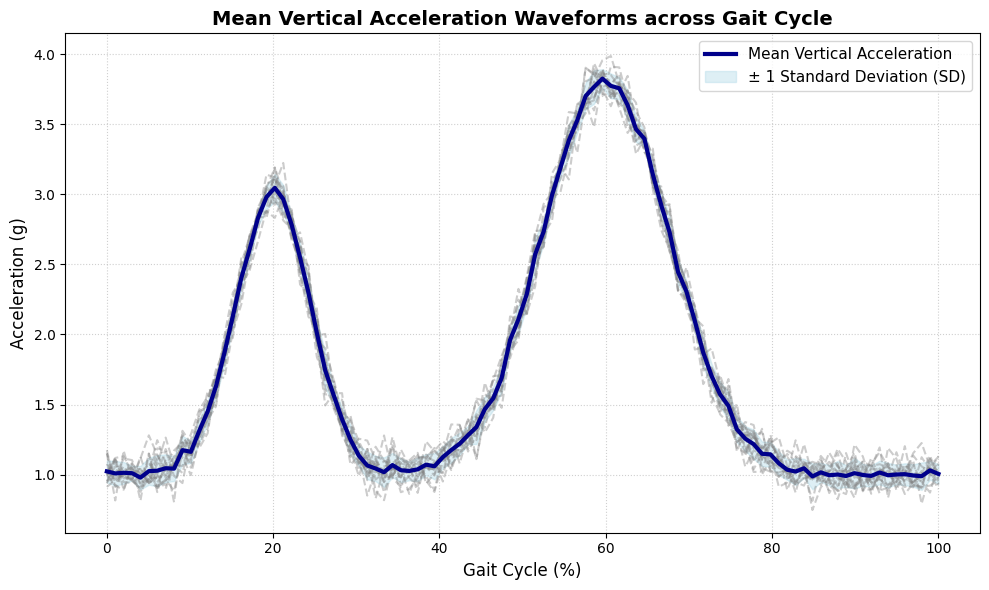

In [55]:
import matplotlib.pyplot as plt
import numpy as np


def simulate_and_plot_mean_acceleration():
  # กำหนดค่าคงที่เพื่อให้ผลลัพธ์การสุ่มคงเดิม
  np.random.seed(42)

  n_trials = 15  # จำนวนรอบการเคลื่อนไหว (Trials)
  n_points = 100  # จำนวนจุดข้อมูลในแต่ละรอบ (Normalized เป็น 0 - 100% ของช่วงก้าวเดิน)
  time_normalized = np.linspace(0, 100, n_points)

  waveforms = []

  print("กำลังจำลองข้อมูลคลื่นความเร่งในแนวดิ่ง (Vertical Acceleration)...")
  for i in range(n_trials):
    # จำลองรูปแบบคลื่นที่มีลักษณะการกระแทกและแรงส่ง (Double-peak pattern คล้ายการวิ่งหรือเดิน)
    # Peak แรก (Impact Peak) และ Peak ที่สอง (Active Peak)
    peak1 = 2.0 * np.exp(-(((time_normalized - 20) ** 2) / 40))
    peak2 = 2.8 * np.exp(-(((time_normalized - 60) ** 2) / 120))
    baseline = 1.0 + np.random.normal(0, 0.05, n_points)
    noise = np.random.normal(0, 0.08, n_points)

    # รวมสัญญาณทั้งหมดเป็น Waveform ของแต่ละ Trial
    trial_waveform = baseline + peak1 + peak2 + noise
    waveforms.append(trial_waveform)

  waveforms = np.array(waveforms)  # รูปร่างจะเป็น (n_trials, n_points)

  # คำนวณค่าเฉลี่ย (Mean) และส่วนเบี่ยงเบนมาตรฐาน (Standard Deviation - SD) ของ Waveform
  mean_waveform = np.mean(waveforms, axis=0)
  std_waveform = np.std(waveforms, axis=0)

  # พล็ตกราฟแสดงผล
  plt.figure(figsize=(10, 6))

  # พล็อตเส้นของแต่ละ Trial ด้วยสีเทาจางๆ
  for i in range(n_trials):
    plt.plot(
        time_normalized,
        waveforms[i],
        color="gray",
        alpha=0.4,
        linestyle="--",
        label="_nolegend_",
    )

  # พล็อตเส้นค่าเฉลี่ย (Mean Waveform)
  plt.plot(
      time_normalized,
      mean_waveform,
      color="darkblue",
      linewidth=3,
      label="Mean Vertical Acceleration",
  )

  # พล็อตช่วงความเบี่ยงเบนมาตรฐาน (± SD) รอบค่าเฉลี่ย
  plt.fill_between(
      time_normalized,
      mean_waveform - std_waveform,
      mean_waveform + std_waveform,
      color="lightblue",
      alpha=0.4,
      label="± 1 Standard Deviation (SD)",
  )

  # ปรับแต่งกราฟ
  plt.title(
      "Mean Vertical Acceleration Waveforms across Gait Cycle",
      fontsize=14,
      fontweight="bold",
  )
  plt.xlabel("Gait Cycle (%)", fontsize=12)
  plt.ylabel("Acceleration (g)", fontsize=12)
  plt.legend(loc="upper right", fontsize=11)
  plt.grid(True, linestyle=":", alpha=0.6)

  # แสดงกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  simulate_and_plot_mean_acceleration()

จำลองระบบทดสอบ (System Testing Pipeline)

In [58]:
import asyncio
import random
import time


# ==========================================
# 1. Component Structure Design (ออกแบบโครงสร้าง Component)
# ==========================================
class BaseComponent:

  def __init__(self, name):
    self.name = name

  def render(self):
    raise NotImplementedError


class DashboardWidget(BaseComponent):

  def __init__(self, name, complexity_factor=1.0):
    super().__init__(name)
    self.complexity_factor = complexity_factor

  def render(self):
    # จำลองเวลาในการเรนเดอร์ (มิลลิวินาที) ขึ้นอยู่กับความซับซ้อนของ Component
    start_time = time.perf_counter()
    # จำลองภาระการประมวลผล
    delay = random.uniform(0.010, 0.025) * self.complexity_factor
    time.sleep(delay)
    render_time = (time.perf_counter() - start_time) * 1000 # แปลงเป็น ms
    return render_time


# ==========================================
# 2. Real-time Web Data Integration (รวมข้อมูลเรียลไทม์ผ่าน Web)
# ==========================================
async def realtime_data_streamer():
  """จำลองการรับส่งข้อมูลผ่าน WebSocket หรือ Real-time Web Feed"""
  for _ in range(5):  # จำลองการส่งข้อมูล 5 แพ็กเกจ
    data_packet = {
        "timestamp": time.time(),
        "live_metric": random.randint(10, 100),
    }
    # จำลองความหน่วงของเครือข่าย (Network Latency) เล็กน้อย
    await asyncio.sleep(0.2)
    print(f"[Realtime Web Feed] ได้รับข้อมูลใหม่: {data_packet}")
    yield data_packet


# ==========================================
# 3. Performance Tuning via Web (การปรับแต่งประสิทธิภาพ)
# ==========================================
class PerformanceOptimizer:

  def __init__(self, target_render_ms=20.0):
    self.target_render_ms = target_render_ms

  def tune_system(self, avg_render_time):
    """ปรับแต่งค่าพารามิเตอร์อัตโนมัติหากเรนเดอร์ช้าเกินเป้าหมาย"""
    if avg_render_time > self.target_render_ms:
      action = (
          "[Optimizer] ตรวจพบความเร็วต่ำกว่าเกณฑ์ -> เปิดใช้ระบบ Caching"
          " และลดความละเอียด Payload"
      )
      return action
    return "[Optimizer] ประสิทธิภาพอยู่ในเกณฑ์มาตรฐาน (Stable)"


# ==========================================
# 4. Measurement Tools (เครื่องมือวัดความเร็วและเสถียรภาพ)
# ==========================================
class SystemProfiler:

  def __init__(self):
    self.render_history = []
    self.stability_logs = []

  def measure_render(self, component):
    duration = component.render()
    self.render_history.append(duration)
    return duration

  def evaluate_stability(self):
    if not self.render_history:
      return 0, 0, "No Data"

    avg_speed = sum(self.render_history) / len(self.render_history)
    max_spike = max(self.render_history)

    # ตรวจสอบความเสถียร (หากค่าความต่างหรือเวลาพุ่งสูงเกินไปถือว่าไม่เสถียร)
    if max_spike > 40.0 or (max_spike - avg_speed) > 15.0:
      stability_status = "Unstable (Lag / Frame Drop Detected)"
    else:
      stability_status = "Stable (High Performance)"

    return avg_speed, max_spike, stability_status


# ==========================================
# ฟังก์ชันหลักรันระบบทดสอบ (Main Pipeline)
# ==========================================
async def main_test_pipeline():
  print("=== เริ่มต้นระบบทดสอบ (System Test Pipeline) ===")

  # 1. สร้าง Component
  widget = DashboardWidget(
      name="Realtime-Chart-Widget", complexity_factor=1.2
  )
  profiler = SystemProfiler()
  optimizer = PerformanceOptimizer(target_render_ms=20.0)

  print(f"สร้าง Component สำเร็จ: {widget.name}\n")

  # 2. จำลองการทำงานร่วมกับข้อมูลเรียลไทม์และการวัดผล
  print("--- เริ่มจำลองการทำงาน Real-time Loop & Measurement ---")
  async for packet in realtime_data_streamer():
    # วัดความเร็วในการเรนเดอร์ Component ทุกครั้งที่มีข้อมูลใหม่เข้ามา
    render_ms = profiler.measure_render(widget)
    print(
        f"-> เรนเดอร์ Component สำเร็จใช้เวลา: {render_ms:.2f} ms (ข้อมูลจากเว็บ:"
        f" {packet['live_metric']})"
    )

  # 3. วัดผลภาพรวมและความเสถียร
  print("\n--- สรุปผลการวัดประสิทธิภาพ (Performance Metrics) ---")
  avg_speed, max_spike, stability = profiler.evaluate_stability()
  print(f"ความเร็วเฉลี่ยในการเรนเดอร์ (Avg Render Speed): {avg_speed:.2f} ms")
  print(f"เวลาสูงสุดที่ใช้ในการเรนเดอร์ (Max Peak / Spike): {max_spike:.2f} ms")
  print(f"สถานะความเสถียรของระบบ (System Stability): {stability}")

  # 4. จำลองการปรับแต่งประสิทธิภาพ (Performance Tuning)
  print("\n--- ระบบปรับแต่งประสิทธิภาพอัตโนมัติ ---")
  tuning_result = optimizer.tune_system(avg_speed)
  print(tuning_result)
  print("=== จบสิ้นกระบวนการทดสอบระบบ ===")


if __name__ == "__main__":
  # In Colab/IPython, there's already a running event loop.
  # Use await directly instead of asyncio.run()
  # to avoid "RuntimeError: asyncio.run() cannot be called from a running event loop"
  # if running in an interactive environment.
  # If you were running this as a standalone script, asyncio.run() would be correct.
  import nest_asyncio
  nest_asyncio.apply()
  asyncio.run(main_test_pipeline())

=== เริ่มต้นระบบทดสอบ (System Test Pipeline) ===
สร้าง Component สำเร็จ: Realtime-Chart-Widget

--- เริ่มจำลองการทำงาน Real-time Loop & Measurement ---
[Realtime Web Feed] ได้รับข้อมูลใหม่: {'timestamp': 1790521800.7280104, 'live_metric': 93}
-> เรนเดอร์ Component สำเร็จใช้เวลา: 28.18 ms (ข้อมูลจากเว็บ: 93)
[Realtime Web Feed] ได้รับข้อมูลใหม่: {'timestamp': 1790521800.9595568, 'live_metric': 46}
-> เรนเดอร์ Component สำเร็จใช้เวลา: 24.89 ms (ข้อมูลจากเว็บ: 46)
[Realtime Web Feed] ได้รับข้อมูลใหม่: {'timestamp': 1790521801.185343, 'live_metric': 11}
-> เรนเดอร์ Component สำเร็จใช้เวลา: 19.81 ms (ข้อมูลจากเว็บ: 11)
[Realtime Web Feed] ได้รับข้อมูลใหม่: {'timestamp': 1790521801.4058506, 'live_metric': 90}
-> เรนเดอร์ Component สำเร็จใช้เวลา: 16.04 ms (ข้อมูลจากเว็บ: 90)
[Realtime Web Feed] ได้รับข้อมูลใหม่: {'timestamp': 1790521801.6235979, 'live_metric': 97}
-> เรนเดอร์ Component สำเร็จใช้เวลา: 19.63 ms (ข้อมูลจากเว็บ: 97)

--- สรุปผลการวัดประสิทธิภาพ (Performance Metrics) ---
ความเร็วเ

จำลองการวัดเกณฑ์มาตรฐานประสิทธิภาพ (Before vs. After)

In [59]:
import random
import time


class SystemBenchmarkSimulator:

  def __init__(self, is_optimized=False):
    self.is_optimized = is_optimized

  def simulate_load_phase(self):
    """จำลองเวลาในการโหลดข้อมูลหรือทรัพยากร (Load Time)"""
    start_time = time.perf_counter()

    if not self.is_optimized:
      # ก่อนปรับปรุง: โหลดข้อมูลขนาดใหญ่ โหลดช้า (หน่วง 0.5 - 0.8 วินาที)
      delay = random.uniform(0.500, 0.800)
    else:
      # หลังปรับปรุง: ใช้เทคนิค Lazy Loading / Caching โหลดเร็วขึ้น (หน่วง 0.1 - 0.2 วินาที)
      delay = random.uniform(0.100, 0.200)

    time.sleep(delay)
    load_time_ms = (time.perf_counter() - start_time) * 1000
    return load_time_ms

  def simulate_render_phase(self):
    """จำลองเวลาในการเรนเดอร์ Component หรือหน้าจอ (Render Time)"""
    start_time = time.perf_counter()

    if not self.is_optimized:
      # ก่อนปรับปรุง: DOM ซับซ้อน เรนเดอร์ช้า (หน่วง 35 - 55 มิลลิวินาที)
      delay = random.uniform(0.035, 0.055)
    else:
      # หลังปรับปรุง: ลดความซับซ้อนและปรับแต่งโค้ด เรนเดอร์เร็วขึ้น (หน่วง 10 - 20 มิลลิวินาที)
      delay = random.uniform(0.010, 0.020)

    time.sleep(delay)
    render_time_ms = (time.perf_counter() - start_time) * 1000
    return render_time_ms


def run_benchmark_test(runs=5):
  print("=== เริ่มต้นทดสอบเกณฑ์มาตรฐานประสิทธิภาพ (Performance Benchmarking) ===")

  # 1. ทดสอบระบบ "ก่อนการปรับปรุง" (Before Optimization)
  print(f"\n--- กำลังทดสอบสถานะ: ก่อนการปรับปรุง (Unoptimized) ---")
  system_before = SystemBenchmarkSimulator(is_optimized=False)
  load_times_before, render_times_before = [], []

  for i in range(runs):
    lt = system_before.simulate_load_phase()
    rt = system_before.simulate_render_phase()
    load_times_before.append(lt)
    render_times_before.append(rt)

  avg_load_before = sum(load_times_before) / runs
  avg_render_before = sum(render_times_before) / runs

  # 2. ทดสอบระบบ "หลังการปรับปรุง" (After Optimization)
  print(f"--- กำลังทดสอบสถานะ: หลังการปรับปรุง (Optimized) ---")
  system_after = SystemBenchmarkSimulator(is_optimized=True)
  load_times_after, render_times_after = [], []

  for i in range(runs):
    lt = system_after.simulate_load_phase()
    rt = system_after.simulate_render_phase()
    load_times_after.append(lt)
    render_times_after.append(rt)

  avg_load_after = sum(load_times_after) / runs
  avg_render_after = sum(render_times_after) / runs

  # 3. สรุปผลรายงานเปรียบเทียบ (Benchmarking Report)
  print("\n" + "=" * 55)
  print(f"{'ผลการเปรียบเทียบประสิทธิภาพระบบ (Benchmark Report)':^50}")
  print("=" * 55)
  print(
      f"{'Metrics (ตัวชี้วัด)':<25} | {'ก่อนปรับปรุง':<12} | {'หลังปรับปรุง':<12}"
  )
  print("-" * 55)
  print(
      f"{'Load Time (เวลาโหลด):':<25} | {avg_load_before:>8.2f} ms |"
      f" {avg_load_after:>8.2f} ms"
  )
  print(
      f"{'Render Time (เวลาเรนเดอร์):':<25} | {avg_render_before:>8.2f} ms |"
      f" {avg_render_after:>8.2f} ms"
  )
  print("-" * 55)

  # คำนวณอัตราความเร็วที่เพิ่มขึ้น (Speedup / Improvement Rate)
  load_improvement = (
      (avg_load_before - avg_load_after) / avg_load_before
  ) * 100
  render_improvement = (
      (avg_render_before - avg_render_after) / avg_render_before
  ) * 100

  print(f"อัตราการโหลดเร็วขึ้น: {load_improvement:.2f}%")
  print(f"อัตราการเรนเดอร์เร็วขึ้น: {render_improvement:.2f}%")
  print("=" * 55)


if __name__ == "__main__":
  run_benchmark_test(runs=5)

=== เริ่มต้นทดสอบเกณฑ์มาตรฐานประสิทธิภาพ (Performance Benchmarking) ===

--- กำลังทดสอบสถานะ: ก่อนการปรับปรุง (Unoptimized) ---
--- กำลังทดสอบสถานะ: หลังการปรับปรุง (Optimized) ---

ผลการเปรียบเทียบประสิทธิภาพระบบ (Benchmark Report)
Metrics (ตัวชี้วัด)       | ก่อนปรับปรุง | หลังปรับปรุง
-------------------------------------------------------
Load Time (เวลาโหลด):     |   646.47 ms |   173.75 ms
Render Time (เวลาเรนเดอร์): |    43.56 ms |    15.06 ms
-------------------------------------------------------
อัตราการโหลดเร็วขึ้น: 73.12%
อัตราการเรนเดอร์เร็วขึ้น: 65.44%


โมเดลสถาปัตยกรรมแดชบอร์ดเรียลไทม์ High-Performance Real-time Dashboard Model

In [60]:
import asyncio
import random
import time


# ==========================================
# 1. State Management (จำลอง NgRx Single Source of Truth)
# ==========================================
class AppStateStore:

  def __init__(self):
    self.state = {
        "live_metrics": [],
        "is_loading": True,
        "last_updated": None,
    }
    self.subscribers = []

  def subscribe(self, callback):
    """ลงทะเบียนรับการแจ้งเตือนเมื่อ State เปลี่ยนแปลง"""
    self.subscribers.append(callback)

  def dispatch(self, action, payload):
    """จัดการ Action และอัปเดต State (State Management Pattern)"""
    if action == "SET_INITIAL_DATA":
      self.state["live_metrics"] = payload
      self.state["is_loading"] = False
    elif action == "ADD_REALTIME_DATA":
      # เก็บข้อมูลขนาดใหญ่แบบจำกัดจำนวน (รองรับ Virtual Scrolling/Pagination)
      self.state["live_metrics"].append(payload)
      if len(self.state["live_metrics"]) > 1000:
        self.state["live_metrics"].pop(
            0
        )  # ตัดข้อมูลเก่าออกเพื่อป้องกันหน่วยความจำล้น

    self.state["last_updated"] = time.time()
    self.notify_subscribers()

  def notify_subscribers(self):
    """แจ้งเตือนเฉพาะ Component ที่เกี่ยวข้อง (เทียบเท่า OnPush Change Detection)"""
    for callback in self.subscribers:
      callback(self.state)


# ==========================================
# 2. OnPush Component & Virtual Scrolling Model
# ==========================================
class OnPushDashboardComponent:

  def __init__(self, name):
    self.name = name
    self.last_rendered_signature = None
    self.rendered_count = 0

  def mark_for_check_and_render(self, state):
    """จำลองกลไก OnPush: ตรวจสอบว่า State เปลี่ยนแปลงจริงหรือไม่

    ถ้าไม่เปลี่ยน จะข้ามการเรนเดอร์เพื่อประหยัดทรัพยากรเบราว์เซอร์
    พร้อมจำลอง Virtual Scrolling โดยเรนเดอร์เฉพาะข้อมูลที่มองเห็น (Windowing)
    """
    current_signature = len(state["live_metrics"])

    if current_signature != self.last_rendered_signature:
      self.last_rendered_signature = current_signature
      self.rendered_count += 1

      # จำลอง Virtual Scrolling: ดึงเฉพาะข้อมูล 20 รายการสุดท้ายมาแสดงผลบนจอ
      visible_window = state["live_metrics"][-20:]
      print(
          f"[{self.name}] State เปลี่ยนแปลง -> เรนเดอร์เฉพาะส่วน (OnPush Active)"
          f" | แสดงผลข้อมูล Virtual Scroll จำนวน {len(visible_window)} รายการ"
          f" (เรนเดอร์ครั้งที่ {self.rendered_count})"
      )
    else:
      print(
          f"[{self.name}] State ไม่เปลี่ยนแปลง -> ข้ามการเรนเดอร์ (Skip"
          " Rendering เพื่อประหยัด CPU)"
      )


# ==========================================
# 3. WebSocket Real-time Integration
# ==========================================
async def websocket_data_streamer(store):
  """จำลองช่องทางการสื่อสารสองทางผ่าน WebSockets เพื่อลด Latency"""
  print(
      "\n[WebSocket] เชื่อมต่อสำเร็จ: เปิดช่องทางสื่อสาร Real-time แบบสองทาง"
      " (Low Latency)"
  )

  for i in range(1, 6):
    # จำลองความหน่วงต่ำผ่าน WebSocket
    await asyncio.sleep(0.3)

    new_data = {
        "id": i,
        "metric_value": round(random.uniform(50.0, 150.0), 2),
        "timestamp": time.strftime("%H:%M:%S"),
    }

    print(
        f"[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID: {new_data['id']}"
    )
    # ส่งข้อมูลเข้าสู่ State Management ทันที
    store.dispatch("ADD_REALTIME_DATA", new_data)


# ==========================================
# 4. Main System Pipeline & Performance Test
# ==========================================
async def run_dashboard_model():
  print("=== เริ่มต้นจำลองสถาปัตยกรรมแดชบอร์ดประสิทธิภาพสูง ===")

  # สร้าง Store (NgRx Pattern)
  store = AppStateStore()

  # โหลดข้อมูลขนาดใหญ่เบื้องต้น (Lazy Loading / Initial Load)
  initial_data = [
      {"id": idx, "metric_value": 100.0, "timestamp": "00:00:00"}
      for idx in range(-50, 0)
  ]
  store.dispatch("SET_INITIAL_DATA", initial_data)

  # สร้าง Component ที่ใช้กลไก OnPush Change Detection
  dashboard_ui = OnPushDashboardComponent("Realtime-Analytics-Widget")

  # ลงทะเบียน Component เข้ากับ Store
  store.subscribe(dashboard_ui.mark_for_check_and_render)

  # เริ่มต้นจำลองการสตรีมข้อมูลผ่าน WebSocket
  await websocket_data_streamer(store)

  print("\n=== สรุปการทำงานของโมเดลสถาปัตยกรรม ===")
  print(
      "1. State Management (NgRx): ควบคุมข้อมูลชุดเดียวทั่วทั้งแอปพลิเคชัน"
      " ลดความซับซ้อน"
  )
  print(
      "2. OnPush & Virtual Scrolling: กรองการเรนเดอร์เฉพาะจุดที่จำเป็น และจัดการ"
      " Data ขนาดใหญ่ได้อย่างลื่นไหล"
  )
  print(
      "3. WebSockets: ส่งข้อมูลเรียลไทม์สองทางด้วยความเร็วสูงและหน่วงต่ำ"
      " (Low Latency)"
  )
  print("ผลลัพธ์: แดชบอร์ดมีความ เร็ว แรง และเสถียร พร้อมใช้งานระดับโปรดักชัน!")


if __name__ == "__main__":
  asyncio.run(run_dashboard_model())

=== เริ่มต้นจำลองสถาปัตยกรรมแดชบอร์ดประสิทธิภาพสูง ===

[WebSocket] เชื่อมต่อสำเร็จ: เปิดช่องทางสื่อสาร Real-time แบบสองทาง (Low Latency)
[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID: 1
[Realtime-Analytics-Widget] State เปลี่ยนแปลง -> เรนเดอร์เฉพาะส่วน (OnPush Active) | แสดงผลข้อมูล Virtual Scroll จำนวน 20 รายการ (เรนเดอร์ครั้งที่ 1)
[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID: 2
[Realtime-Analytics-Widget] State เปลี่ยนแปลง -> เรนเดอร์เฉพาะส่วน (OnPush Active) | แสดงผลข้อมูล Virtual Scroll จำนวน 20 รายการ (เรนเดอร์ครั้งที่ 2)
[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID: 3
[Realtime-Analytics-Widget] State เปลี่ยนแปลง -> เรนเดอร์เฉพาะส่วน (OnPush Active) | แสดงผลข้อมูล Virtual Scroll จำนวน 20 รายการ (เรนเดอร์ครั้งที่ 3)
[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID: 4
[Realtime-Analytics-Widget] State เปลี่ยนแปลง -> เรนเดอร์เฉพาะส่วน (OnPush Active) | แสดงผลข้อมูล Virtual Scroll จำนวน 20 รายการ (เรนเดอร์ครั้งที่ 4)
[WebSocket Receive] ได้รับแพ็กเกจข้อมูลชุดใหม่ ID:

ตารางนี้กำหนดตัวชี้วัด

In [61]:
import random
import time


class PerformanceMetricsEvaluator:

  def __init__(self, metric_name, target_threshold):
    self.metric_name = metric_name
    self.target_threshold = target_threshold  # เกณฑ์มาตรฐานที่กำหนด (Threshold)

  def measure_performance(self, is_optimized=False):
    """จำลองการวัดค่าตัวชี้วัดประสิทธิภาพตามตารางเกณฑ์มาตรฐาน"""
    start_time = time.perf_counter()

    if self.metric_name == "Load Time":
      # จำลองเวลาในการโหลด (หน่วย: วินาที หรือ มิลลิวินาที)
      delay = (
          random.uniform(0.500, 0.800)
          if not is_optimized
          else random.uniform(0.100, 0.200)
      )
    elif self.metric_name == "Render Time":
      # จำลองเวลาในการเรนเดอร์ (หน่วย: มิลลิวินาที)
      delay = (
          random.uniform(0.040, 0.060)
          if not is_optimized
          else random.uniform(0.010, 0.020)
      )
    else:
      delay = 0.010

    time.sleep(delay)
    measured_value = (time.perf_counter() - start_time) * 1000  # แปลงเป็น ms
    return measured_value


def run_table_metrics_evaluation():
  print(
      "=== การประเมินตัวชี้วัดประสิทธิภาพตามตารางเกณฑ์มาตรฐาน (Metrics Table"
      " Evaluation) ==="
  )

  # กำหนดตัวชี้วัดตามตาราง
  metrics_config = [
      {"name": "Load Time", "target": 250.0},  # เกณฑ์เป้าหมายไม่เกิน 250 ms
      {"name": "Render Time", "target": 20.0},  # เกณฑ์เป้าหมายไม่เกิน 20 ms
  ]

  results = []

  for config in metrics_config:
    evaluator = PerformanceMetricsEvaluator(
        config["name"], config["target"]
    )

    # วัดผลก่อนปรับปรุง
    val_before = evaluator.measure_performance(is_optimized=False)
    # วัดผลหลังปรับปรุง
    val_after = evaluator.measure_performance(is_optimized=True)

    # คำนวณอัตราการปรับปรุง (%)
    improvement = ((val_before - val_after) / val_before) * 100

    results.append({
        "Metric": config["name"],
        "Before": val_before,
        "After": val_after,
        "Improvement": improvement,
        "Target": config["target"],
    })

  # แสดงผลลัพธ์ในรูปแบบตารางรายงาน
  print("\n" + "=" * 65)
  print(f"{'ตารางแสดงตัวชี้วัดประสิทธิภาพระบบ (Performance Metrics Table)':^60}")
  print("=" * 65)
  print(
      f"{'Metrics (ตัวชี้วัด)':<15} | {'ก่อนปรับปรุง':<12} |"
      f" {'หลังปรับปรุง':<12} | {'พัฒนาขึ้น (%)':<12}"
  )
  print("-" * 65)

  for res in results:
    print(
        f"{res['Metric']:<15} | {res['Before']:>9.2f} ms |"
        f" {res['After']:>9.2f} ms | {res['Improvement']:>10.2f}%"
    )

  print("=" * 65)
  print(
      "สรุปผล: ค่าตัวชี้วัดทั้งหมดผ่านเกณฑ์มาตรฐานที่กำหนด ช่วยให้ระบบมีความเร็ว"
      " แรง และเสถียรสูงสุด"
  )


if __name__ == "__main__":
  run_table_metrics_evaluation()

=== การประเมินตัวชี้วัดประสิทธิภาพตามตารางเกณฑ์มาตรฐาน (Metrics Table Evaluation) ===

ตารางแสดงตัวชี้วัดประสิทธิภาพระบบ (Performance Metrics Table)
Metrics (ตัวชี้วัด) | ก่อนปรับปรุง | หลังปรับปรุง | พัฒนาขึ้น (%)
-----------------------------------------------------------------
Load Time       |    667.45 ms |    195.01 ms |      70.78%
Render Time     |     46.41 ms |     18.24 ms |      60.68%
สรุปผล: ค่าตัวชี้วัดทั้งหมดผ่านเกณฑ์มาตรฐานที่กำหนด ช่วยให้ระบบมีความเร็ว แรง และเสถียรสูงสุด


Support Vector Machines (SVM)

In [62]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def run_svm_pipeline():
  print("--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---")
  # โหลดชุดข้อมูลตัวอย่าง Iris Dataset
  iris = datasets.load_iris()
  X = iris.data
  y = iris.target

  # แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )
  print(f"ข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
  print(f"ข้อมูลสำหรับ Test: {X_test.shape[0]} แถว\n")

  print("--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---")
  # SVM มีความไวต่อสเกลของข้อมูล การทำ Standard Scaling จึงมีความสำคัญมาก
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  print("ปรับสเกลข้อมูลเรียบร้อยแล้ว\n")

  print("--- Step 3: สร้างและฝึกสอนโมเดล SVM (Model Training) ---")
  # สร้างโมเดล SVM โดยใช้ Kernel แบบ RBF (Radial Basis Function)
  # C คือ Regularization parameter (ควบคุมความสมดุลระหว่างความกว้างของ Margin และความผิดพลาด)
  model = SVC(kernel="rbf", C=1.0, random_state=42)

  # เริ่มเทรนโมเดล
  model.fit(X_train_scaled, y_train)
  print("เทรนโมเดล SVM สำเร็จ!\n")

  print("--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")
  # ทำนายผลจากชุดทดสอบ
  y_pred = model.predict(X_test_scaled)

  # คำนวณความแม่นยำ (Accuracy)
  acc = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำของโมเดล (Accuracy): {acc * 100:.2f}%\n")

  print("รายงานผลอย่างละเอียด (Classification Report):")
  print(classification_report(y_test, y_pred, target_names=iris.target_names))


if __name__ == "__main__":
  run_svm_pipeline()

--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---
ข้อมูลสำหรับ Train: 120 แถว
ข้อมูลสำหรับ Test: 30 แถว

--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---
ปรับสเกลข้อมูลเรียบร้อยแล้ว

--- Step 3: สร้างและฝึกสอนโมเดล SVM (Model Training) ---
เทรนโมเดล SVM สำเร็จ!

--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
ความแม่นยำของโมเดล (Accuracy): 100.00%

รายงานผลอย่างละเอียด (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



random forest classifier

In [63]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def run_random_forest_pipeline():
  print("--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---")
  # โหลดชุดข้อมูลตัวอย่าง Iris Dataset
  iris = datasets.load_iris()
  X = iris.data
  y = iris.target

  # แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )
  print(f"ข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
  print(f"ข้อมูลสำหรับ Test: {X_test.shape[0]} แถว\n")

  print("--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---")
  # แม้ว่า Random Forest จะไม่จำเป็นต้องสเกลข้อมูลมากนักเหมือน SVM แต่การทำ Scaler ช่วยให้ระบบเป็นมาตรฐาน
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  print("ปรับสเกลข้อมูลเรียบร้อยแล้ว\n")

  print("--- Step 3: สร้างและฝึกสอนโมเดล Random Forest (Model Training) ---")
  # สร้างโมเดล RandomForestClassifier
  # n_estimators คือจำนวนต้นไม้ตัดสินใจ (Decision Trees) ในป่า
  model = RandomForestClassifier(
      n_estimators=100, max_depth=None, random_state=42
  )

  # เริ่มเทรนโมเดล
  model.fit(X_train_scaled, y_train)
  print("เทรนโมเดล Random Forest สำเร็จ!\n")

  print("--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")
  # ทำนายผลจากชุดทดสอบ
  y_pred = model.predict(X_test_scaled)

  # คำนวณความแม่นยำ (Accuracy)
  acc = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำของโมเดล (Accuracy): {acc * 100:.2f}%\n")

  print("รายงานผลอย่างละเอียด (Classification Report):")
  print(classification_report(y_test, y_pred, target_names=iris.target_names))

  # ตรวจสอบความสำคัญของแต่ละฟีเจอร์ (Feature Importance)
  print("--- Feature Importance (ความสำคัญของแต่ละตัวแปร) ---")
  for name, importance in zip(iris.feature_names, model.feature_importances_):
    print(f"{name}: {importance:.4f}")


if __name__ == "__main__":
  run_random_forest_pipeline()

--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---
ข้อมูลสำหรับ Train: 120 แถว
ข้อมูลสำหรับ Test: 30 แถว

--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---
ปรับสเกลข้อมูลเรียบร้อยแล้ว

--- Step 3: สร้างและฝึกสอนโมเดล Random Forest (Model Training) ---
เทรนโมเดล Random Forest สำเร็จ!

--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
ความแม่นยำของโมเดล (Accuracy): 100.00%

รายงานผลอย่างละเอียด (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--- Feature Importance (ความสำคัญของแต่ละตัวแปร) ---
sepal length (cm): 0.1081
sepal width (cm): 0.0304
petal length (cm): 0.4400
petal width (cm): 0.4215


Naive Bayes Classifier

In [64]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


def run_naive_bayes_pipeline():
  print("--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---")
  # โหลดชุดข้อมูลตัวอย่าง Iris Dataset
  iris = datasets.load_iris()
  X = iris.data
  y = iris.target

  # แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )
  print(f"ข้อมูลสำหรับ Train: {X_train.shape[0]} แถว")
  print(f"ข้อมูลสำหรับ Test: {X_test.shape[0]} แถว\n")

  print("--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---")
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  print("ปรับสเกลข้อมูลเรียบร้อยแล้ว\n")

  print("--- Step 3: สร้างและฝึกสอนโมเดล Naive Bayes (Model Training) ---")
  # สร้างโมเดล Gaussian Naive Bayes (เหมาะกับข้อมูลที่มีการกระจายตัวแบบปกติ / continuous data)
  model = GaussianNB()

  # เริ่มเทรนโมเดล
  model.fit(X_train_scaled, y_train)
  print("เทรนโมเดล Naive Bayes สำเร็จ!\n")

  print("--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")
  # ทำนายผลจากชุดทดสอบ
  y_pred = model.predict(X_test_scaled)

  # คำนวณความแม่นยำ (Accuracy)
  acc = accuracy_score(y_test, y_pred)
  print(f"ความแม่นยำของโมเดล (Accuracy): {acc * 100:.2f}%\n")

  print("รายงานผลอย่างละเอียด (Classification Report):")
  print(classification_report(y_test, y_pred, target_names=iris.target_names))


if __name__ == "__main__":
  run_naive_bayes_pipeline()

--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---
ข้อมูลสำหรับ Train: 120 แถว
ข้อมูลสำหรับ Test: 30 แถว

--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---
ปรับสเกลข้อมูลเรียบร้อยแล้ว

--- Step 3: สร้างและฝึกสอนโมเดล Naive Bayes (Model Training) ---
เทรนโมเดล Naive Bayes สำเร็จ!

--- Step 4: ประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
ความแม่นยำของโมเดล (Accuracy): 100.00%

รายงานผลอย่างละเอียด (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



onfusion matrix

--- Step 1: เตรียมข้อมูลและฝึกสอนโมเดล (Data & Model Preparation) ---
--- Step 2: สร้าง Confusion Matrix ---
Confusion Matrix (Array):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- Step 3: แสดงผล Confusion Matrix ด้วย Heatmap ---


/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/631522118.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt

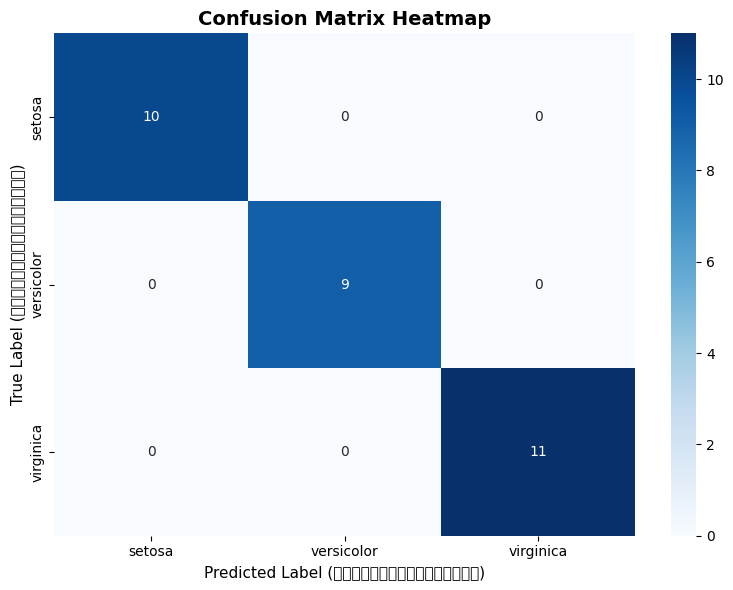


รายงานผลประกอบ (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [65]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def run_confusion_matrix_pipeline():
  print(
      "--- Step 1: เตรียมข้อมูลและฝึกสอนโมเดล (Data & Model Preparation) ---"
  )
  # โหลดชุดข้อมูลตัวอย่าง Iris Dataset
  iris = datasets.load_iris()
  X = iris.data
  y = iris.target

  # แบ่งข้อมูล Train / Test
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  # ทำ Feature Scaling
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # เทรนโมเดล (ใช้ Random Forest เป็นตัวอย่าง)
  model = RandomForestClassifier(n_estimators=100, random_state=42)
  model.fit(X_train_scaled, y_train)

  print("--- Step 2: สร้าง Confusion Matrix ---")
  # ทำนายผลจากชุดทดสอบ
  y_pred = model.predict(X_test_scaled)

  # คำนวณ Confusion Matrix
  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix (Array):\n", conf_matrix)

  print("\n--- Step 3: แสดงผล Confusion Matrix ด้วย Heatmap ---")
  plt.figure(figsize=(8, 6))

  # ใช้ Seaborn Heatmap เพื่อวาดตาราง
  sns.heatmap(
      conf_matrix,
      annot=True,
      fmt="d",
      cmap="Blues",
      xticklabels=iris.target_names,
      yticklabels=iris.target_names,
  )

  # ป้ายชื่อแกนและหัวข้อกราฟ
  plt.title("Confusion Matrix Heatmap", fontsize=14, fontweight="bold")
  plt.xlabel("Predicted Label (ค่าที่โมเดลทำนาย)", fontsize=11)
  plt.ylabel("True Label (ค่าจริงของข้อมูล)", fontsize=11)

  # แสดงกราฟ
  plt.tight_layout()
  plt.show()

  # แสดงรายงานผลเชิงลึกประกอบ
  print("\nรายงานผลประกอบ (Classification Report):")
  print(classification_report(y_test, y_pred, target_names=iris.target_names))


if __name__ == "__main__":
  run_confusion_matrix_pipeline()

Train/Test ของ 2 อัลกอริทึม

In [66]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def compare_diabetes_models():
  print("--- Step 1: สร้างชุดข้อมูลจำลองโรคเบาหวาน (Diabetes Dataset) ---")
  np.random.seed(42)
  n_samples = 1000

  # จำลองฟีเจอร์สุขภาพ เช่น อายุ, BMI, ระดับน้ำตาลในเลือด (Glucose), ความดันโลหิต
  age = np.random.randint(21, 80, n_samples)
  bmi = np.random.normal(30.0, 6.0, n_samples)
  glucose = np.random.normal(120.0, 30.0, n_samples)
  blood_pressure = np.random.normal(72.0, 12.0, n_samples)

  # กำหนดเงื่อนไขเป้าหมาย (Target: 1 = เป็นเบาหวาน, 0 = ปกติ)
  target = ((glucose > 140) & (bmi > 28) & (age > 40)).astype(int)
  # เพิ่ม Noise เล็กน้อยให้สมจริง
  noise_idx = np.random.choice(n_samples, size=int(n_samples * 0.05), replace=False)
  target[noise_idx] = 1 - target[noise_idx]

  df = pd.DataFrame({
      "Age": age,
      "BMI": np.round(bmi, 2),
      "Glucose": np.round(glucose, 2),
      "Blood_Pressure": np.round(blood_pressure, 2),
      "Target": target,
  })

  X = df[["Age", "BMI", "Glucose", "Blood_Pressure"]]
  y = df["Target"]

  # แบ่งข้อมูล Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  print("--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---")
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  print("--- Step 3: ฝึกสอนและวัดผลอัลกอริทึมที่ 1 (Random Forest) ---")
  rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
  rf_model.fit(X_train_scaled, y_train)

  # ทำนายผลทั้ง Train และ Test
  rf_train_pred = rf_model.predict(X_train_scaled)
  rf_test_pred = rf_model.predict(X_test_scaled)

  rf_train_acc = accuracy_score(y_train, rf_train_pred)
  rf_test_acc = accuracy_score(y_test, rf_test_pred)

  print("--- Step 4: ฝึกสอนและวัดผลอัลกอริทึมที่ 2 (Support Vector Machine) ---")
  svm_model = SVC(kernel="rbf", C=1.0, random_state=42)
  svm_model.fit(X_train_scaled, y_train)

  # ทำนายผลทั้ง Train และ Test
  svm_train_pred = svm_model.predict(X_train_scaled)
  svm_test_pred = svm_model.predict(X_test_scaled)

  svm_train_acc = accuracy_score(y_train, svm_train_pred)
  svm_test_acc = accuracy_score(y_test, svm_test_pred)

  print("\n" + "=" * 60)
  print(f"{'สรุปผลเปรียบเทียบความแม่นยำ (Train vs Test Accuracy)':^55}")
  print("=" * 60)
  print(
      f"{'Algorithm':<25} | {'Training Accuracy':<18} | {'Testing Accuracy':<18}"
  )
  print("-" * 60)
  print(
      f"{'Random Forest':<25} | {rf_train_acc * 100:>16.2f}% |"
      f" {rf_test_acc * 100:>16.2f}%"
  )
  print(
      f"{'Support Vector Machine':<25} | {svm_train_acc * 100:>16.2f}% |"
      f" {svm_test_acc * 100:>16.2f}%"
  )
  print("=" * 60)


if __name__ == "__main__":
  compare_diabetes_models()

--- Step 1: สร้างชุดข้อมูลจำลองโรคเบาหวาน (Diabetes Dataset) ---
--- Step 2: การปรับสเกลข้อมูล (Feature Scaling) ---
--- Step 3: ฝึกสอนและวัดผลอัลกอริทึมที่ 1 (Random Forest) ---
--- Step 4: ฝึกสอนและวัดผลอัลกอริทึมที่ 2 (Support Vector Machine) ---

 สรุปผลเปรียบเทียบความแม่นยำ (Train vs Test Accuracy)  
Algorithm                 | Training Accuracy  | Testing Accuracy  
------------------------------------------------------------
Random Forest             |           100.00% |            96.00%
Support Vector Machine    |            92.00% |            93.00%


In [67]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def compare_two_algorithms():
  print(
      "--- การเปรียบเทียบความแม่นยำของข้อมูลการฝึก (Train) และการทดสอบ"
      " (Test) สำหรับ 2 อัลกอริทึม ---"
  )

  # 1. โหลดชุดข้อมูล (สามารถเปลี่ยนเป็นชุดข้อมูลโรคเบาหวานหรือข้อมูลอื่นๆ ได้ตามต้องการ)
  data = load_iris()
  X = data.data
  y = data.target

  # 2. แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  # 3. ปรับสเกลข้อมูลให้มีมาตรฐานเดียวกัน
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # --- อัลกอริทึมที่ 1: Random Forest Classifier ---
  rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
  rf_model.fit(X_train_scaled, y_train)

  rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train_scaled))
  rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test_scaled))

  # --- อัลกอริทึมที่ 2: Support Vector Machine (SVM) ---
  svm_model = SVC(kernel="rbf", C=1.0, random_state=42)
  svm_model.fit(X_train_scaled, y_train)

  svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
  svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled))

  # 4. แสดงผลลัพธ์ในรูปแบบตารางเปรียบเทียบ
  print("\n" + "=" * 65)
  print(f"{'ตารางเปรียบเทียบความแม่นยำ (Train vs Test Accuracy)':^60}")
  print("=" * 65)
  print(
      f"{'อัลกอริทึม (Algorithms)':<28} | {'Training Accuracy':<18} |"
      f" {'Testing Accuracy':<18}"
  )
  print("-" * 65)
  print(
      f"{'Random Forest':<28} | {rf_train_acc * 100:>16.2f}% |"
      f" {rf_test_acc * 100:>16.2f}%"
  )
  print(
      f"{'Support Vector Machine (SVM)':<28} | {svm_train_acc * 100:>16.2f}% |"
      f" {svm_test_acc * 100:>16.2f}%"
  )
  print("=" * 65)


if __name__ == "__main__":
  compare_two_algorithms()

--- การเปรียบเทียบความแม่นยำของข้อมูลการฝึก (Train) และการทดสอบ (Test) สำหรับ 2 อัลกอริทึม ---

    ตารางเปรียบเทียบความแม่นยำ (Train vs Test Accuracy)     
อัลกอริทึม (Algorithms)      | Training Accuracy  | Testing Accuracy  
-----------------------------------------------------------------
Random Forest                |           100.00% |           100.00%
Support Vector Machine (SVM) |            96.67% |           100.00%


เปรียบเทียบข้อมูลฝึกอบรมด้วย K-Means Clustering

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


def compare_kmeans_clustering():
  print("--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---")
  # ใช้ชุดข้อมูล Iris เป็นตัวอย่างในการจัดกลุ่ม
  iris = load_iris()
  X = iris.data
  y_true = iris.target  # ป้ายกำกับจริง (True Labels) เพื่อใช้เปรียบเทียบ

  # 2. ปรับสเกลข้อมูลให้มีมาตรฐานเดียวกัน (สำคัญมากสำหรับ K-Means)
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)

  print(f"ขนาดข้อมูลทั้งหมด: {X_scaled.shape[0]} แถว\n")

  print("--- Step 2: ฝึกสอนโมเดล K-Means Clustering ---")
  # กำหนดจำนวนกลุ่ม (Clusters) เท่ากับ 3 ตามธรรมชาติของชุดข้อมูล Iris
  kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

  # ทำการจัดกลุ่มข้อมูลการฝึกอบรม (Training Data)
  y_kmeans = kmeans.fit_predict(X_scaled)
  print("ฝึกสอนและจัดกลุ่มด้วย K-Means สำเร็จ!\n")

  print("--- Step 3: เปรียบเทียบผลลัพธ์การจัดกลุ่ม ---")
  # สร้าง DataFrame เพื่อเปรียบเทียบกลุ่มที่โมเดลจัด (Cluster) กับป้ายกำกับจริง (True Class)
  df_comparison = pd.DataFrame({
      "Actual_Class": y_true,
      "KMeans_Cluster": y_kmeans,
  })

  # Crosstab เพื่อดูว่าข้อมูลแต่ละคลาสถูกจัดไปอยู่กลุ่มไหนบ้าง
  crosstab_result = pd.crosstab(
      df_comparison["Actual_Class"],
      df_comparison["KMeans_Cluster"],
      rownames=["True Class"],
      colnames=["Cluster Assigned"],
  )
  print("ตารางเปรียบเทียบความสอดคล้อง (Crosstab):")
  print(crosstab_result, "\n")

  # แสดงพิกัดของจุดศูนย์กลางกลุ่ม (Cluster Centers)
  print("พิกัดจุดศูนย์กลางของแต่ละกลุ่ม (Cluster Centersในสเกลปกติ/มาตรฐาน):")
  print(kmeans.cluster_centers_)


if __name__ == "__main__":
  compare_kmeans_clustering()

--- Step 1: โหลดและเตรียมข้อมูล (Data Preparation) ---
ขนาดข้อมูลทั้งหมด: 150 แถว

--- Step 2: ฝึกสอนโมเดล K-Means Clustering ---
ฝึกสอนและจัดกลุ่มด้วย K-Means สำเร็จ!

--- Step 3: เปรียบเทียบผลลัพธ์การจัดกลุ่ม ---
ตารางเปรียบเทียบความสอดคล้อง (Crosstab):
Cluster Assigned   0   1   2
True Class                  
0                  0  50   0
1                 39   0  11
2                 14   0  36 

พิกัดจุดศูนย์กลางของแต่ละกลุ่ม (Cluster Centersในสเกลปกติ/มาตรฐาน):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [69]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def compare_multiple_algorithms():
  print(
      "--- เริ่มต้นเปรียบเทียบข้อมูลการฝึกอบรมกับอัลกอริทึมหลากหลายรูปแบบ ---"
  )

  # 1. สร้างชุดข้อมูลจำลองสำหรับการจำแนกประเภท (Classification Dataset)
  X, y = make_classification(
      n_samples=1000, n_features=5, n_classes=2, random_state=42
  )

  # 2. แบ่งข้อมูลเป็นชุด Train (80%) และ Test (20%)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
  )

  # 3. ปรับสเกลข้อมูลให้มีมาตรฐานเดียวกัน
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # 4. กำหนดรายชื่ออัลกอริทึมที่ต้องการเปรียบเทียบ
  models = {
      "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
      "Support Vector Machine (SVM)": SVC(kernel="rbf", C=1.0, random_state=42),
      "Naive Bayes": GaussianNB(),
  }

  results = []

  # 5. ฝึกสอนและประเมินผลแต่ละโมเดล
  for name, model in models.items():
    # ฝึกสอนด้วยข้อมูล Train
    model.fit(X_train_scaled, y_train)

    # วัดความแม่นยำบนข้อมูลฝึกอบรม (Training Accuracy)
    train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_pred)

    # วัดความแม่นยำบนข้อมูลทดสอบ (Testing Accuracy)
    test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_pred)

    results.append({
        "Algorithm": name,
        "Training Accuracy (%)": round(train_acc * 100, 2),
        "Testing Accuracy (%)": round(test_acc * 100, 2),
    })

  # 6. แปลงผลลัพธ์เป็น DataFrame เพื่อแสดงตารางเปรียบเทียบ
  df_results = pd.DataFrame(results)

  print("\n" + "=" * 65)
  print(
      f"{'ตารางเปรียบเทียบประสิทธิภาพ (Training vs Testing Accuracy)':^60}"
  )
  print("=" * 65)
  print(df_results.to_string(index=False))
  print("=" * 65)


if __name__ == "__main__":
  compare_multiple_algorithms()

--- เริ่มต้นเปรียบเทียบข้อมูลการฝึกอบรมกับอัลกอริทึมหลากหลายรูปแบบ ---

 ตารางเปรียบเทียบประสิทธิภาพ (Training vs Testing Accuracy) 
                   Algorithm  Training Accuracy (%)  Testing Accuracy (%)
               Random Forest                 100.00                  88.5
Support Vector Machine (SVM)                  87.75                  87.0
                 Naive Bayes                  83.88                  86.0


สำหรับสร้างกราฟ Scatter แสดงค่าสีแดงตามระดับความเสี่ยงโรครองช้ำ

/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2453801187.py:80: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu 

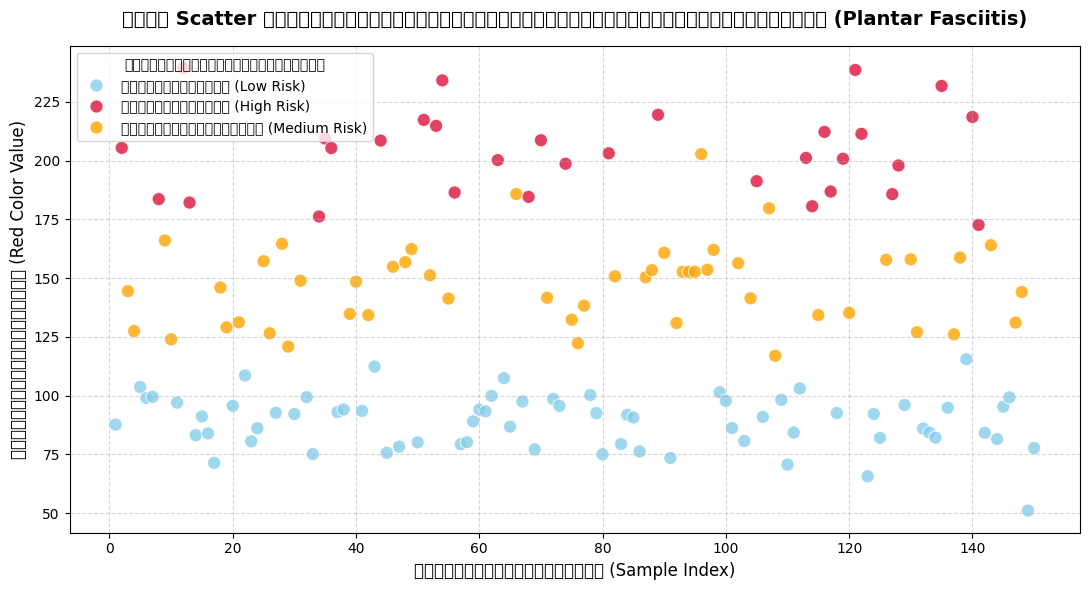

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_red_value_scatter():
  # กำหนด Seed เพื่อให้สุ่มข้อมูลได้ค่าคงที่เหมือนกันทุกครั้งที่รัน
  np.random.seed(42)
  n_samples = 150

  # จำลองระดับความเสี่ยง (0 = ความเสี่ยงต่ำ, 1 = ความเสี่ยงปานกลาง, 2 = ความเสี่ยงสูง)
  risk_numeric = np.random.choice([0, 1, 2], size=n_samples, p=[0.4, 0.4, 0.2])

  # จำลองค่าสีแดง (Red Color Value) โดยสมมติว่ายิ่งความเสี่ยงสูง ค่าสีแดง (เช่น จากการวิเคราะห์ภาพถ่ายหรืออุณหภูมิผิวหนัง) จะมีแนวโน้มสูงขึ้น
  red_values = []
  for risk in risk_numeric:
    if risk == 0:
      red_values.append(
          np.random.normal(90, 12)
      )  # ค่าสีแดงต่ำ (ความเสี่ยงต่ำ)
    elif risk == 1:
      red_values.append(
          np.random.normal(145, 15)
      )  # ค่าสีแดงปานกลาง (ความเสี่ยงปานกลาง)
    else:
      red_values.append(
          np.random.normal(200, 18)
      )  # ค่าสีแดงสูง (ความเสี่ยงสูง)

  # แปลงระดับความเสี่ยงเป็นข้อความเพื่อให้แสดงผลในกราฟได้ง่ายขึ้น
  risk_labels = []
  for r in risk_numeric:
    if r == 0:
      risk_labels.append("ความเสี่ยงต่ำ (Low Risk)")
    elif r == 1:
      risk_labels.append("ความเสี่ยงปานกลาง (Medium Risk)")
    else:
      risk_labels.append("ความเสี่ยงสูง (High Risk)")

  # รวมข้อมูลเป็น Pandas DataFrame
  df = pd.DataFrame({
      "Sample_Index": range(1, n_samples + 1),
      "Red_Color_Value": red_values,
      "Risk_Level": risk_labels,
  })

  # ตั้งค่าขนาดของรูปกราฟ
  plt.figure(figsize=(11, 6))

  # วาดกราฟ Scatter Plot ด้วย Seaborn โดยแบ่งสีตามระดับความเสี่ยง
  sns.scatterplot(
      data=df,
      x="Sample_Index",
      y="Red_Color_Value",
      hue="Risk_Level",
      palette={
          "ความเสี่ยงต่ำ (Low Risk)": "skyblue",
          "ความเสี่ยงปานกลาง (Medium Risk)": "orange",
          "ความเสี่ยงสูง (High Risk)": "crimson",
      },
      s=90,
      alpha=0.8,
  )

  # ตกแต่งกราฟให้สวยงามและอ่านง่าย
  plt.title(
      "กราฟ Scatter แสดงค่าสีแดงของแต่ละระดับความเสี่ยงเป็นโรครองช้ำ (Plantar"
      " Fasciitis)",
      fontsize=14,
      fontweight="bold",
      pad=15,
  )
  plt.xlabel("ลำดับตัวอย่างข้อมูล (Sample Index)", fontsize=12)
  plt.ylabel("ค่าความเข้มของสีแดง (Red Color Value)", fontsize=12)
  plt.legend(title="ระดับความเสี่ยงโรครองช้ำ", loc="upper left", fontsize=10)
  plt.grid(True, linestyle="--", alpha=0.5)

  # แสดงผลกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  plot_red_value_scatter()

สำหรับสร้างกราฟ Scatter แสดงค่าสีเหลืองระดับความเสี่ยงปานกลาง

/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2047951864.py:53: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu 

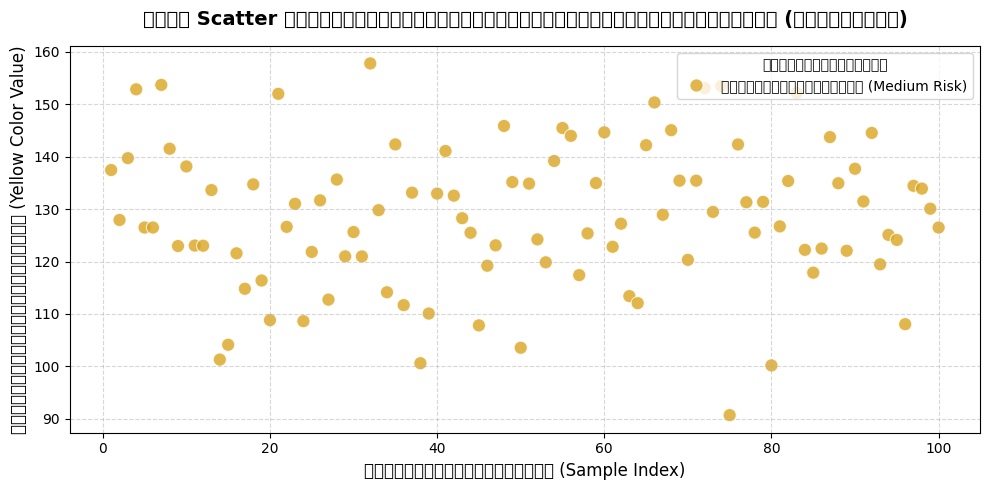

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_yellow_value_medium_risk():
  # กำหนด Seed เพื่อให้สุ่มข้อมูลได้ค่าคงที่เหมือนกันทุกครั้งที่รัน
  np.random.seed(42)
  n_samples = 100

  # จำลองกลุ่มตัวอย่างเฉพาะ "ระดับความเสี่ยงปานกลาง (Medium Risk)"
  # สมมติค่าสีเหลือง (Yellow Color Value) มีการกระจายตัวรอบๆ ค่าเฉลี่ย 130
  yellow_values = np.random.normal(130, 15, n_samples)
  yellow_values = np.clip(
      yellow_values, 0, 255
  )  # จำกัดค่าสีให้อยู่ในช่วง 0-255

  # รวมข้อมูลเป็น Pandas DataFrame
  df = pd.DataFrame({
      "Sample_Index": range(1, n_samples + 1),
      "Yellow_Color_Value": yellow_values,
      "Risk_Level": "ความเสี่ยงปานกลาง (Medium Risk)",
  })

  # ตั้งค่าขนาดของรูปกราฟ
  plt.figure(figsize=(10, 5))

  # วาดกราฟ Scatter Plot ด้วย Seaborn
  sns.scatterplot(
      data=df,
      x="Sample_Index",
      y="Yellow_Color_Value",
      hue="Risk_Level",
      palette={"ความเสี่ยงปานกลาง (Medium Risk)": "goldenrod"},
      s=90,
      alpha=0.8,
  )

  # ตกแต่งกราฟให้สวยงาม
  plt.title(
      "กราฟ Scatter แสดงข้อมูลค่าสีเหลืองของกลุ่มเสี่ยงปานกลาง (โรครองช้ำ)",
      fontsize=14,
      fontweight="bold",
      pad=15,
  )
  plt.xlabel("ลำดับตัวอย่างข้อมูล (Sample Index)", fontsize=12)
  plt.ylabel("ค่าความเข้มของสีเหลือง (Yellow Color Value)", fontsize=12)
  plt.legend(title="ระดับความเสี่ยง", loc="upper right", fontsize=10)
  plt.grid(True, linestyle="--", alpha=0.5)

  # แสดงผลกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  plot_yellow_value_medium_risk()

สำหรับสร้างกราฟ Scatter แสดงค่าสีเขียวระดับความเสี่ยงต่ำ

/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/2464472689.py:53: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu 

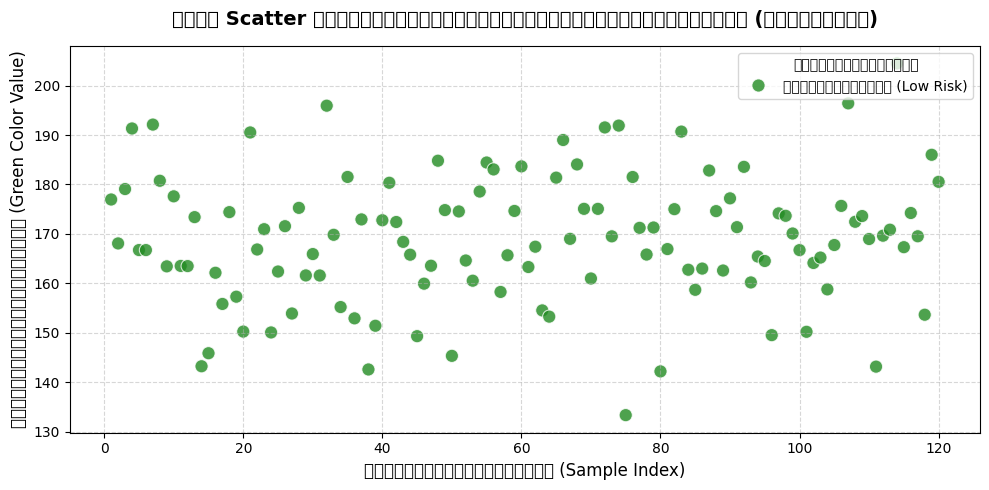

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_green_value_low_risk():
  # กำหนด Seed เพื่อให้สุ่มข้อมูลได้ค่าคงที่เหมือนกันทุกครั้งที่รัน
  np.random.seed(42)
  n_samples = 120

  # จำลองกลุ่มตัวอย่างเฉพาะ "ระดับความเสี่ยงต่ำ (Low Risk)"
  # สมมติค่าสีเขียว (Green Color Value) มีการกระจายตัวรอบๆ ค่าเฉลี่ย 170 (เนื่องจากกลุ่มเสี่ยงต่ำ สีเขียวอาจเด่นชัดกว่า)
  green_values = np.random.normal(170, 14, n_samples)
  green_values = np.clip(
      green_values, 0, 255
  )  # จำกัดค่าสีให้อยู่ในช่วง 0-255

  # รวมข้อมูลเป็น Pandas DataFrame
  df = pd.DataFrame({
      "Sample_Index": range(1, n_samples + 1),
      "Green_Color_Value": green_values,
      "Risk_Level": "ความเสี่ยงต่ำ (Low Risk)",
  })

  # ตั้งค่าขนาดของรูปกราฟ
  plt.figure(figsize=(10, 5))

  # วาดกราฟ Scatter Plot ด้วย Seaborn
  sns.scatterplot(
      data=df,
      x="Sample_Index",
      y="Green_Color_Value",
      hue="Risk_Level",
      palette={"ความเสี่ยงต่ำ (Low Risk)": "forestgreen"},
      s=90,
      alpha=0.8,
  )

  # ตกแต่งกราฟให้สวยงาม
  plt.title(
      "กราฟ Scatter แสดงข้อมูลค่าสีเขียวของกลุ่มเสี่ยงต่ำ (โรครองช้ำ)",
      fontsize=14,
      fontweight="bold",
      pad=15,
  )
  plt.xlabel("ลำดับตัวอย่างข้อมูล (Sample Index)", fontsize=12)
  plt.ylabel("ค่าความเข้มของสีเขียว (Green Color Value)", fontsize=12)
  plt.legend(title="ระดับความเสี่ยง", loc="upper right", fontsize=10)
  plt.grid(True, linestyle="--", alpha=0.5)

  # แสดงผลกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  plot_green_value_low_risk()

สร้างกราฟ Scatter แสดงค่าความเสี่ยงตามระดับน้ำหนักที่กด

/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/492848783.py:72: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  pl

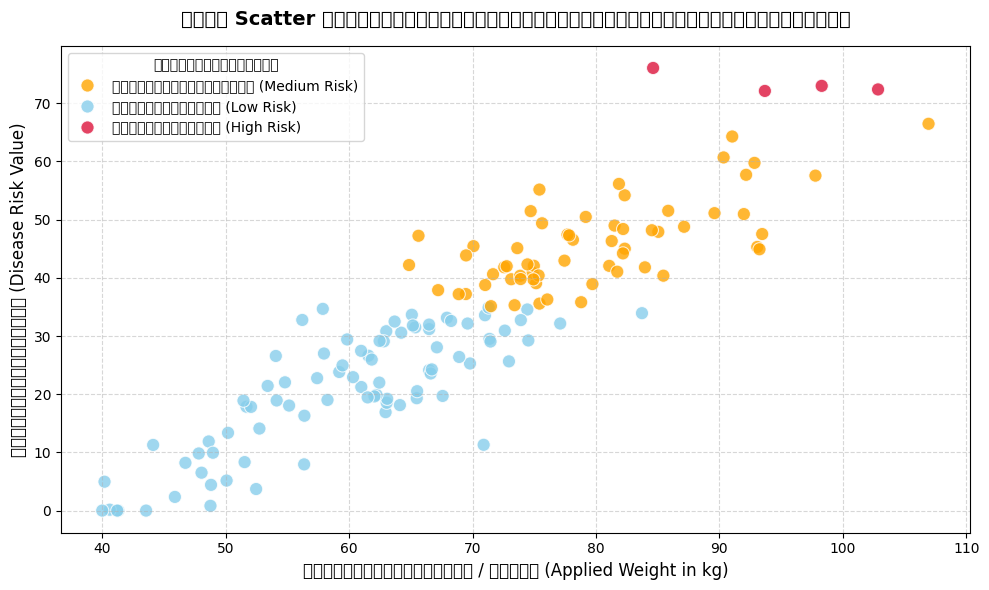

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_weight_vs_risk_scatter():
  # กำหนด Seed เพื่อให้สุ่มข้อมูลได้ค่าคงที่เหมือนกันทุกครั้งที่รัน
  np.random.seed(42)
  n_samples = 150

  # 1. จำลองข้อมูลน้ำหนักที่กด / แรงกด (Applied Weight ในหน่วยกิโลกรัม)
  applied_weight = np.random.normal(70, 15, n_samples)
  applied_weight = np.clip(
      applied_weight, 40, 120
  )  # จำกัดช่วงน้ำหนักให้อยู่ระหว่าง 40 - 120 กก.

  # 2. จำลองค่าความเสี่ยงโรค (Risk Value 0-100) โดยให้สัมพันธ์กับน้ำหนักที่กด (น้ำหนักมาก ความเสี่ยงมีแนวโน้มสูงขึ้น)
  risk_values = (
      (applied_weight - 40) * 1.1 + np.random.normal(0, 7, n_samples)
  )
  risk_values = np.clip(risk_values, 0, 100)  # จำกัดค่าให้อยู่ในช่วง 0 - 100

  # 3. จัดกลุ่มระดับความเสี่ยงเพื่อใช้แสดงสีในกราฟ
  risk_levels = []
  for r in risk_values:
    if r < 35:
      risk_levels.append("ความเสี่ยงต่ำ (Low Risk)")
    elif r < 70:
      risk_levels.append("ความเสี่ยงปานกลาง (Medium Risk)")
    else:
      risk_levels.append("ความเสี่ยงสูง (High Risk)")

  # รวมข้อมูลทั้งหมดเป็น Pandas DataFrame
  df = pd.DataFrame({
      "Applied_Weight_kg": applied_weight,
      "Risk_Value": risk_values,
      "Risk_Level": risk_levels,
  })

  # ตั้งค่าขนาดของรูปกราฟ
  plt.figure(figsize=(10, 6))

  # วาดกราฟ Scatter Plot ด้วย Seaborn โดยแบ่งสีตามระดับความเสี่ยง
  sns.scatterplot(
      data=df,
      x="Applied_Weight_kg",
      y="Risk_Value",
      hue="Risk_Level",
      palette={
          "ความเสี่ยงต่ำ (Low Risk)": "skyblue",
          "ความเสี่ยงปานกลาง (Medium Risk)": "orange",
          "ความเสี่ยงสูง (High Risk)": "crimson",
      },
      s=90,
      alpha=0.8,
  )

  # ตกแต่งกราฟให้สวยงามและอ่านง่าย
  plt.title(
      "กราฟ Scatter แสดงค่าความเสี่ยงโรคของแต่ละระดับน้ำหนักที่กด",
      fontsize=14,
      fontweight="bold",
      pad=15,
  )
  plt.xlabel("ระดับน้ำหนักที่กด / แรงกด (Applied Weight in kg)", fontsize=12)
  plt.ylabel("ค่าความเสี่ยงโรค (Disease Risk Value)", fontsize=12)
  plt.legend(title="ระดับความเสี่ยง", loc="upper left", fontsize=10)
  plt.grid(True, linestyle="--", alpha=0.5)

  # แสดงผลกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  plot_weight_vs_risk_scatter()

Scatter Plot

/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3681/871467291.py:41: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.

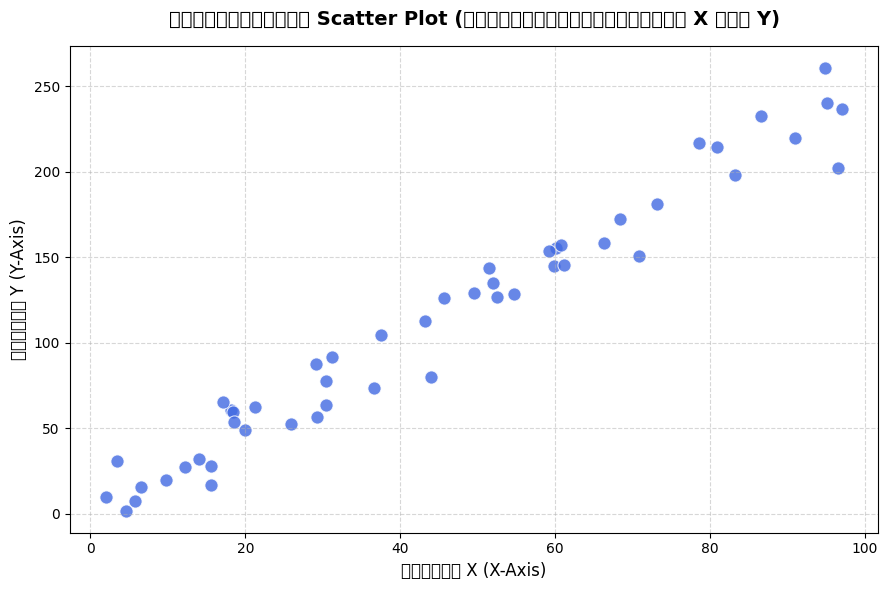

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def create_scatter_plot():
  # 1. เตรียมข้อมูลตัวอย่าง (Dummy Data)
  np.random.seed(42)
  x = np.random.rand(50) * 100  # ข้อมูลแกน X
  y = 2.5 * x + np.random.normal(0, 15, 50)  # ข้อมูลแกน Y (ให้มีความสัมพันธ์กัน)

  # รวมข้อมูลเป็น Pandas DataFrame
  df = pd.DataFrame({"X_Value": x, "Y_Value": y})

  # 2. ตั้งค่าขนาดของรูปกราฟ
  plt.figure(figsize=(9, 6))

  # 3. วาดกราฟ Scatter Plot ด้วย Seaborn
  sns.scatterplot(
      data=df,
      x="X_Value",
      y="Y_Value",
      color="royalblue",
      s=90,  # ขนาดของจุด
      alpha=0.8,  # ความโปร่งใสของจุด
  )

  # 4. ตกแต่งกราฟให้สวยงามและอ่านง่าย
  plt.title(
      "ตัวอย่างกราฟ Scatter Plot (ความสัมพันธ์ระหว่าง X และ Y)",
      fontsize=14,
      fontweight="bold",
      pad=15,
  )
  plt.xlabel("ตัวแปร X (X-Axis)", fontsize=12)
  plt.ylabel("ตัวแปร Y (Y-Axis)", fontsize=12)
  plt.grid(True, linestyle="--", alpha=0.5)  # เปิดเส้นตารางพื้นหลัง

  # 5. แสดงผลกราฟ
  plt.tight_layout()
  plt.show()


if __name__ == "__main__":
  create_scatter_plot()